In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import seaborn as sns
import os
import matplotlib.dates as mdates

In [2]:
# saving year indexed manifests and predictions

# TODO- change to a config file

manifest_path = {}
manifest_path["2023"] = "../../MothSheets_photoManifest_2023.csv" 
all_manifests = {}
all_manifests["2023"] = pd.read_csv(manifest_path["2023"])


preds_path = {}
preds_path["2023"] = "../../Results/InferencePipeline/predictions_2023.csv"
all_preds = {}
all_preds["2023"] = pd.read_csv(preds_path["2023"])

In [3]:
# config file - neat

bin_specs = { 
    "small":
            {
                "sizerange": (0.125,4), #cm^2
                "logrange": (-3.0,2.0), #log(2) units
                "count_col": "count_small",
                "bm_col": "bm_small", 
                "color": "blue",
                "avg_mass": 2.75,
                "class": "small"
            },
    
    "medium-small":
            {
                "sizerange": (4,12), #cm^2
                "logrange": (2.0,3.58),
                "count_col": "count_medium-small",
                "bm_col": "bm_medium-small",
                "color": "orange",
                "avg_mass": 54,
                "class": "medium-small"
            },
    "medium-large":
            {
                "sizerange" : (12,55), #cm^2
                "logrange" : (3.58, 5.78),
                "count_col": "count_medium-large",
                "bm_col": "bm_medium-large",
                "color": "purple",
                "avg_mass": 361,
                "class" : "medium-large"
            },
    "large":
            {
                "sizerange": (55,256), #cm^2
                "logrange": (5.78,8.0),
                "count_col": "count_large",
                "bm_col": "bm_large",
                "color": "skyblue",
                "avg_mass": 418,
                "class": "large"
            }
}
ct_columns = [x["count_col"] for x in bin_specs.values()]
print(ct_columns)
bm_columns = [x["bm_col"] for x in bin_specs.values()]
print(bm_columns)

LOCATIONS = ["WS1","WS4", "WS5", "WS6low", "WS6up"]


#input global parameters

YEAR = "2023"
CURRENT_LOC = "WS1"
binedges = sorted(list(set([v for x in bin_specs.values() for v in x["logrange"]])))
# binedges.update(x["logrange"][0] for x in bin_specs)
print(binedges)

['count_small', 'count_medium-small', 'count_medium-large', 'count_large']
['bm_small', 'bm_medium-small', 'bm_medium-large', 'bm_large']
[-3.0, 2.0, 3.58, 5.78, 8.0]


In [5]:
def retrieve_dataframes(YEAR, CURRENT_LOC):
    #retrieve manifest
    manifest =  all_manifests[YEAR][all_manifests[YEAR]["site"] == CURRENT_LOC]

    #retrive predictions
    preds = all_preds[YEAR][all_preds[YEAR]["site"] == CURRENT_LOC]
    return manifest, preds


def normalise_dataframes(manifest, preds):
    def pad_filename(name):
        parts = str(name).split("_") # expected format: year_site_date_time_camera.JPG , e.g. 2023_WS1_0611_5_WSCT4258.JPG
        if len(parts) >= 5:
            parts[3] = str(parts[3]).zfill(4)
        return "_".join(parts)

    manifest["fileName_old"] = manifest["fileName"]
    manifest["fileName"] = manifest["fileName"].apply(pad_filename)
    return manifest, preds


def merge_and_add_cols(manifest, preds):
    merged = preds.merge(manifest, on="fileName", how="left",suffixes=("_pred", "_manifest"))
    # add columns to merged sheet for trend analysis
    merged["size_log2"] = np.log2(merged["size"])
    merged["timebin"] = merged["dateTime_excel"].apply(lambda x: x.split(" ")[1].split(":")[0])
    merged = merged.sort_values(
        by='night.mmdd',
        key=lambda s: s.astype(str).str[-4:] + s.astype(str).str[-7:-4] + s.astype(str).str[-6:-4]
    )

    # logrange_labels = [x["logrange"] for x in size_specs]
    # class_labels = [x["class"] for x in size_specs]
    
    merged["size_bin"] = pd.cut(merged['size_log2'], bins=binedges, labels = [x["class"] for x in bin_specs.values()], right=True, include_lowest=True)
    return merged


def build_hist(series):
    data = np.array(series)
    plt.figure(figsize=(15,5))

    plt.hist(data, bins=100)
    plt.xlabel("size_in_cm")
    plt.ylabel("frequency")
    plt.title("Spread of Moth Sizes cm for 2023")
    return


def plot_size_hist(merged_df):
    plt.figure(figsize=(20,5))
    data = np.array(merged_df["size_log2"])
    plt.hist(data,bins = binedges, edgecolor="black", color="maroon", alpha=.6)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.xlabel("Size in cms^2, log2 Scale")
    plt.ylabel("Count")
    plt.title("Distribution for Insect Sizes")


def aggregate_by_image(merged_df):
    img_aggregate = (pd.get_dummies(merged_df["size_bin"], prefix="count")
         .join(merged_df[["fileName", "night.mmdd", "dateTime_excel", "timebin"]])
         .groupby(["fileName", "night.mmdd", "dateTime_excel", "timebin"], as_index=False)
         .sum())
    return img_aggregate


def aggregate_by_night(img_aggregate):
    # BY NIGHT MAXIMUM COUNT
    bin_cols = [c for c in img_aggregate.columns if c.startswith("count_")]
    night_aggregate = (
        img_aggregate.groupby("night.mmdd", as_index=False)[bin_cols]
        .max()
    )
    cols_ct = [x["count_col"] for x in bin_specs.values()]
    night_aggregate["total"] = night_aggregate[cols_ct].sum(axis=1)

    cols_bm = [x["bm_col"] for x in bin_specs.values()]
    for k,v in bin_specs.items():
        night_aggregate[v["bm_col"]] = night_aggregate[v["count_col"]]*v["avg_mass"]
    
    night_aggregate["bm_total"] = night_aggregate[cols_bm].sum(axis=1)
    
    return night_aggregate   

def plot_it(night_aggregate):
    # -----------------------------
    # style
    # -----------------------------
    sns.set_theme(
        style="white",
        context="paper",
        rc={
            "axes.spines.top": False,
            "axes.spines.right": False
        }
    )

    BM_YLIM = (0, 6000)


    # -----------------------------
    # data prep
    # -----------------------------
    df = night_aggregate.copy()

    # if night.mmdd is like 611, 620, 705 ...
    df["night.mmdd"] = pd.to_datetime(
        "2023" + df["night.mmdd"].astype(str).str.zfill(4),
        format="%Y%m%d"
    )

    # -----------------------------
    # helper formatting
    # -----------------------------
    def format_date_axis(ax):
        locator = mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
        formatter = mdates.DateFormatter("%b %d")
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(90)
        ax.grid(False)

    # -----------------------------
    # 1) one figure per bin: count + biomass side by side
    # -----------------------------
    for spec in bin_specs.values():
        cols = ["night.mmdd", spec["count_col"], spec["bm_col"]]
        d = df[cols].dropna().sort_values("night.mmdd").copy()

        if d.empty:
            print(f"Skipping {spec['class']} : no data")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(8.2, 2.8), dpi=300, sharex=True)

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["count_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=axes[0]
        )
        axes[0].set_title(spec["class"])
        axes[0].set_xlabel("Date")
        axes[0].set_ylabel("Count")
        format_date_axis(axes[0])

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["bm_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=axes[1]
        )
        axes[1].set_title(spec["class"])
        axes[1].set_xlabel("Date")
        axes[1].set_ylabel("Body Mass (mg)")
        axes[1].set_ylim(BM_YLIM)
        format_date_axis(axes[1])

        fig.suptitle(f"Moths in size bin: {spec['class']}", y=1.03, fontsize=10)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # 2) all bins together: COUNT
    # -----------------------------
    fig, ax = plt.subplots(figsize=(6.0, 2.6), dpi=300)

    for spec in bin_specs.values():
        d = df[["night.mmdd", spec["count_col"]]].dropna().sort_values("night.mmdd").copy()
        if d.empty:
            continue

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["count_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=ax,
            label=spec["class"]
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of moth counts across size bins")
    format_date_axis(ax)

    desired_order = [spec["class"] for spec in bin_specs.values()]
    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(l) for l in desired_order if l in labels]

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Size bin (cm²)",
        frameon=True,
        ncol=1,
        loc="upper right",
        fontsize=6,
        title_fontsize=6,
        handlelength=1.0,
        handletextpad=0.3,
        borderpad=0.2,
        labelspacing=0.2,
        columnspacing=0.6,
    )

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 3) all bins together: BIOMASS
    # -----------------------------
    fig, ax = plt.subplots(figsize=(6.0, 2.6), dpi=300)

    for spec in bin_specs.values():
        d = df[["night.mmdd", spec["bm_col"]]].dropna().sort_values("night.mmdd").copy()
        if d.empty:
            continue

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["bm_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=ax,
            label=spec["class"]
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Body Mass (mg)")
    ax.set_title("Distribution of moth biomass across size bins")
    format_date_axis(ax)

    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(l) for l in desired_order if l in labels]

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Size bin (cm²)",
        frameon=True,
        ncol=1,
        loc="upper right",
        fontsize=6,
        title_fontsize=6,
        handlelength=1.0,
        handletextpad=0.3,
        borderpad=0.2,
        labelspacing=0.2,
        columnspacing=0.6,
    )

    plt.tight_layout()
    plt.show()

In [6]:
def runtrends(yr, site):
    manifesto, preds = retrieve_dataframes(yr, site)
    manifesto, preds = normalise_dataframes(manifesto, preds)
    merged = merge_and_add_cols(manifesto, preds)
    # build_hist(merged["size"])
    # plot_size_hist(merged)
    img_agg = aggregate_by_image(merged)
    night_agg = aggregate_by_night(img_agg)
    # plot_it(night_agg)
    return merged, img_agg, night_agg

In [7]:
night_aggregates = {}
for loc in LOCATIONS:
    night_aggregates.update({loc:runtrends(YEAR,loc)[2]})

In [8]:
count_cols = [x["count_col"] for x in bin_specs.values()]

combined = pd.concat(
    [df.assign(site=site) for site, df in night_aggregates.items()],
    ignore_index = True
)
# display(combined)

money_fig = combined[["night.mmdd","site"] + count_cols].copy()
money_fig[count_cols] = np.sqrt(money_fig[count_cols])
# display(money_fig)


In [9]:
avg_counts = money_fig.groupby("night.mmdd", as_index=False)[count_cols].mean()
sd_counts = money_fig.groupby("night.mmdd", as_index=False)[count_cols].std()
n_counts = money_fig.groupby("night.mmdd", as_index=False)[count_cols].count()
display(money_fig)
display("AVERAGES")
display(avg_counts)
display('STANDARD DDEVIATIONS')
display(sd_counts)
display("N COUNTS")
display(n_counts)

,night.mmdd,site,count_small,count_medium-small,count_medium-large,count_large
0,611,WS1,7.549834,8.602325,2.000000,2.236068
1,620,WS1,6.244998,6.324555,2.645751,2.645751
2,628,WS1,5.291503,4.795832,2.645751,2.449490
3,705,WS1,6.633250,3.316625,2.236068,0.000000
4,712,WS1,5.291503,4.795832,1.732051,0.000000
5,720,WS1,4.472136,3.162278,1.414214,0.000000
6,724,WS1,3.872983,2.449490,2.000000,1.000000
7,802,WS1,3.872983,2.236068,1.000000,0.000000
8,816,WS1,6.480741,3.741657,1.000000,0.000000
9,819,WS1,6.633250,3.000000,1.414214,0.000000


'AVERAGES'

,night.mmdd,count_small,count_medium-small,count_medium-large,count_large
0,611,6.985112,7.508121,2.171389,2.582827
1,620,6.696450,5.995066,2.580331,2.293940
2,628,5.101236,4.503616,2.187656,1.519151
3,705,7.265565,3.971685,1.989263,0.682843
4,712,6.635759,4.387193,1.900057,0.333333
5,720,5.076240,2.840180,1.103553,0.000000
6,724,5.234927,3.320528,1.282843,0.200000
7,802,3.388504,2.216761,1.000000,0.000000
8,816,5.014621,3.913886,1.244017,0.000000
9,819,6.033726,3.352761,0.942809,0.000000


'STANDARD DDEVIATIONS'

,night.mmdd,count_small,count_medium-small,count_medium-large,count_large
0,611,1.394373,1.473372,0.216234,0.324558
1,620,0.486143,0.297955,0.113312,0.326742
2,628,1.312148,0.804239,0.517399,0.604339
3,705,0.717261,0.531180,0.550946,0.645877
4,712,1.204185,0.358903,0.290994,0.577350
5,720,0.987781,0.494470,0.207107,0.000000
6,724,1.656632,0.847125,0.832402,0.447214
7,802,0.526366,0.793070,0.000000,0.000000
8,816,1.510089,0.149154,0.422650,0.000000
9,819,0.625486,0.372147,0.816497,0.000000


'N COUNTS'

,night.mmdd,count_small,count_medium-small,count_medium-large,count_large
0,611,4,4,4,4
1,620,3,3,3,3
2,628,5,5,5,5
3,705,5,5,5,5
4,712,3,3,3,3
5,720,4,4,4,4
6,724,5,5,5,5
7,802,3,3,3,3
8,816,3,3,3,3
9,819,3,3,3,3


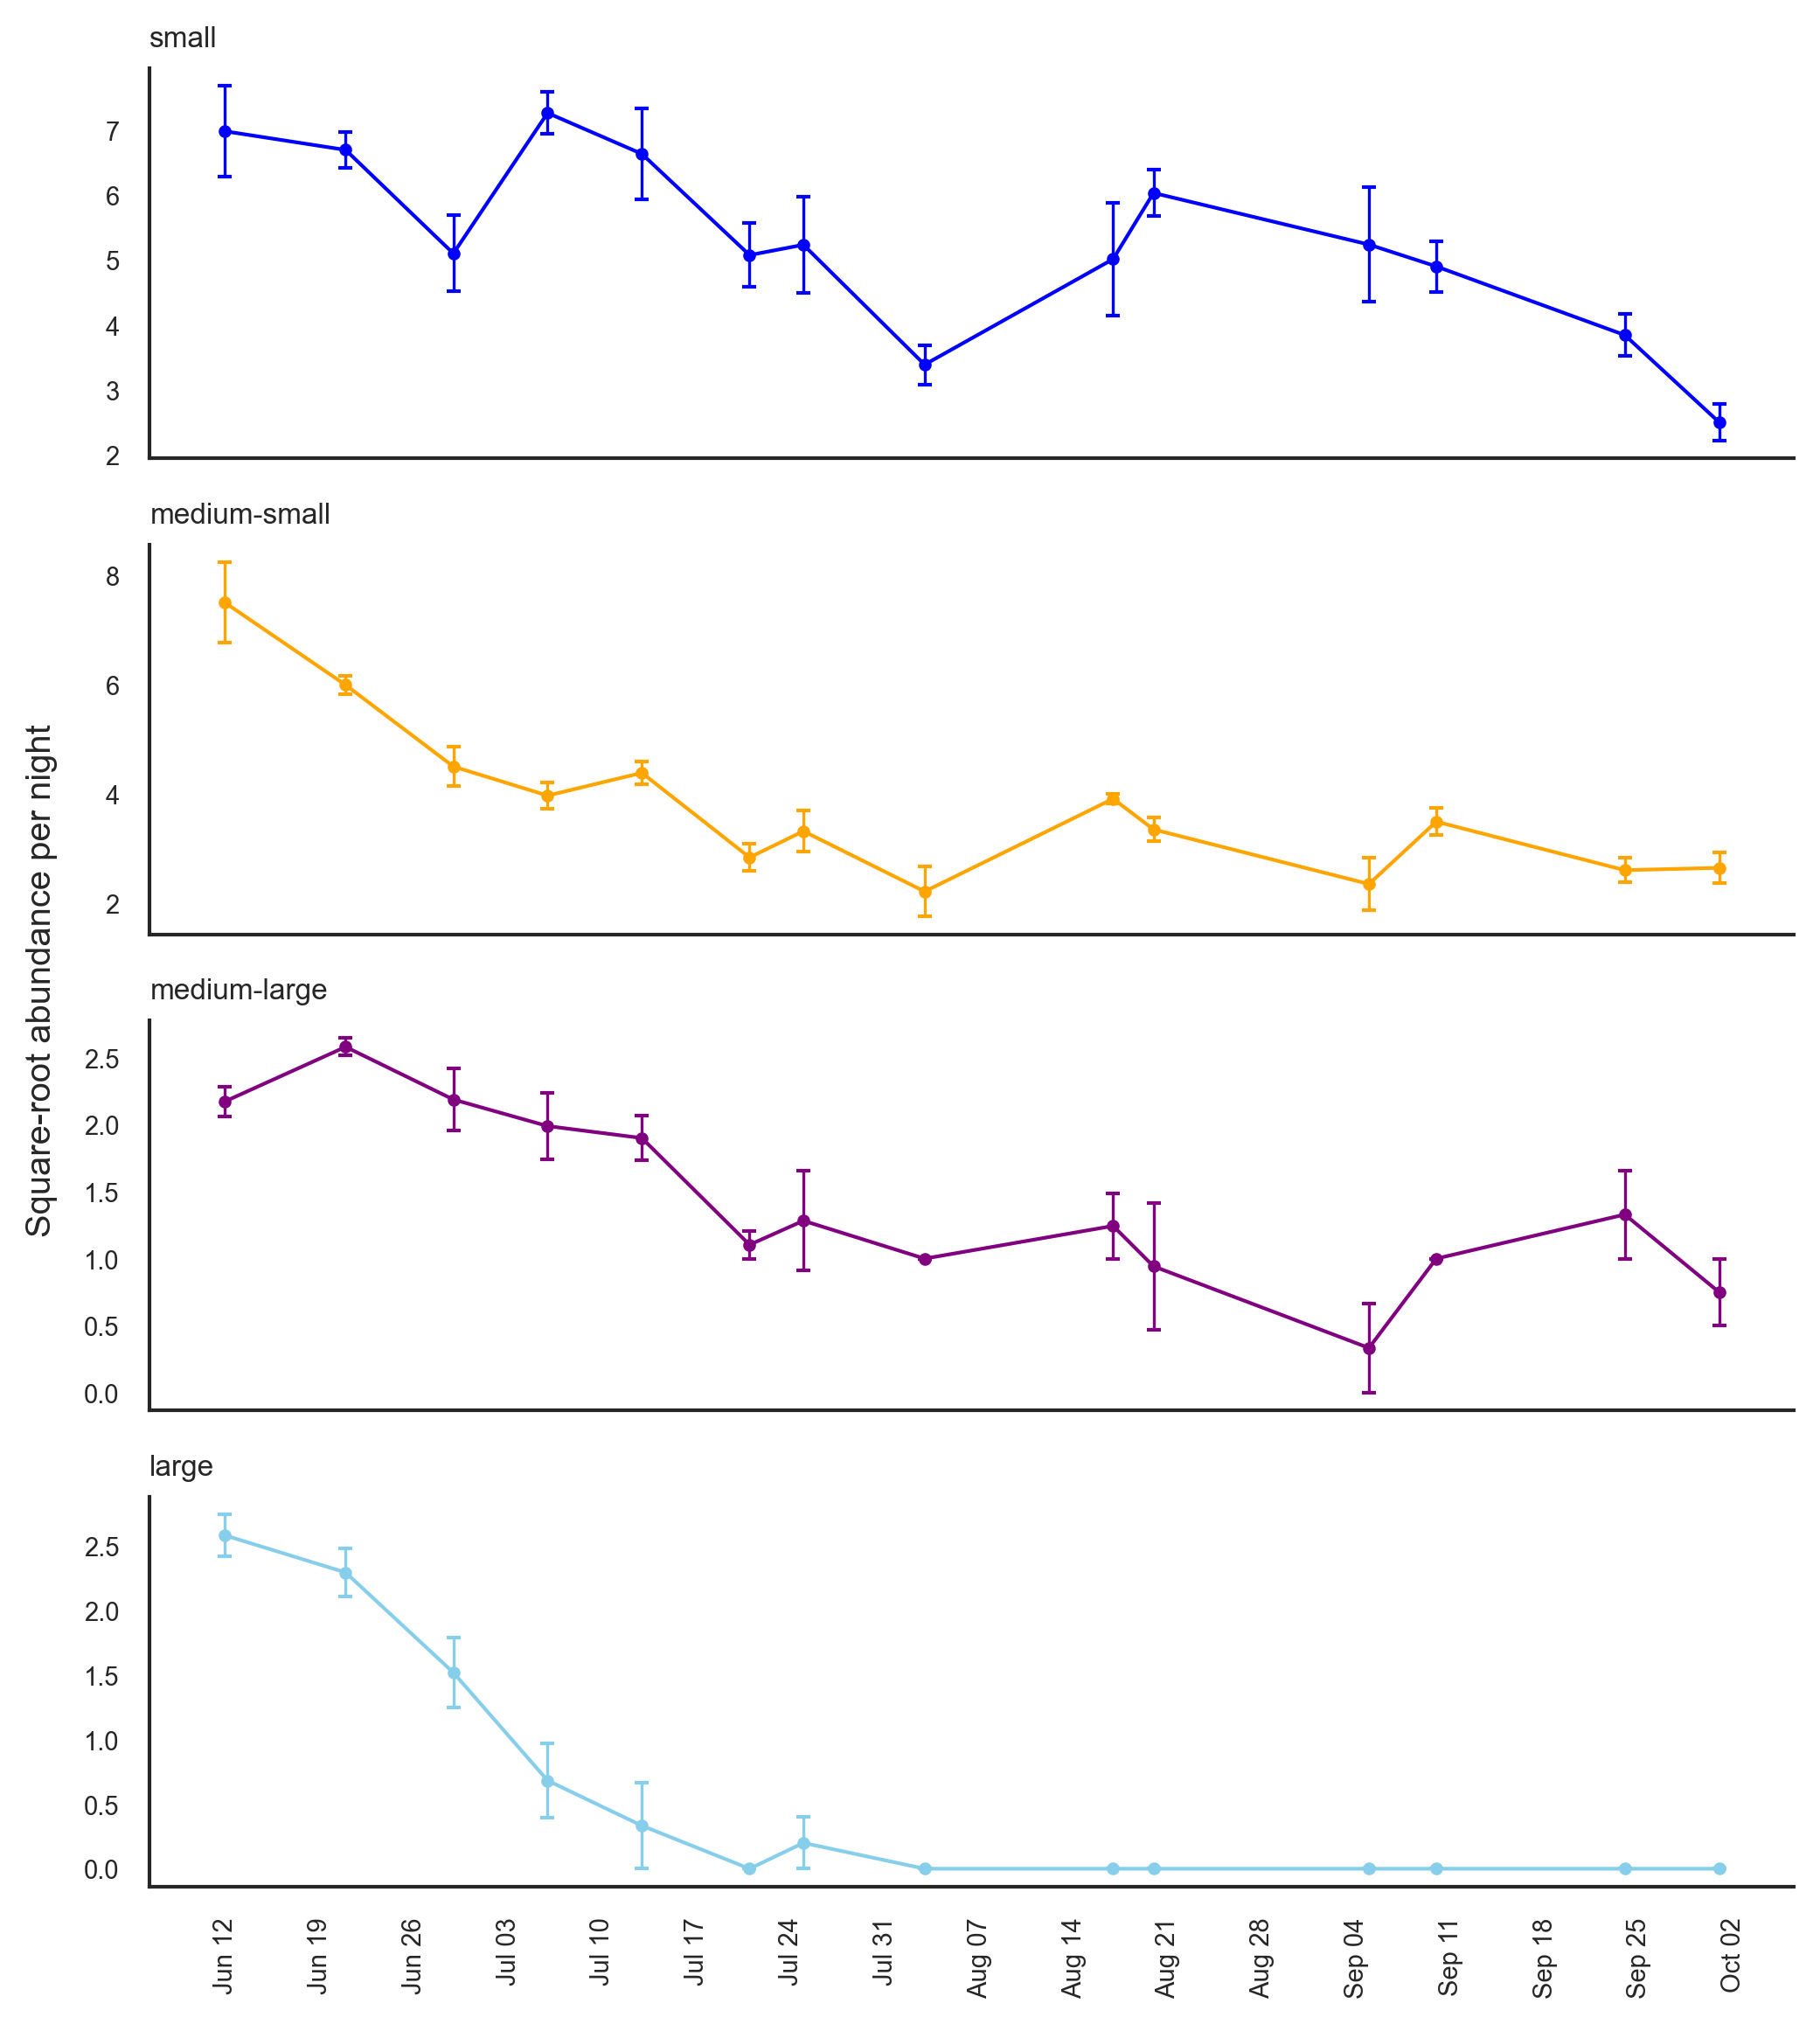

In [ ]:
from scipy.stats import t

plot_df = money_fig.copy()

plot_df["night.mmdd"] = pd.to_datetime(
    YEAR + plot_df["night.mmdd"].astype(str).str.zfill(4),
    format="%Y%m%d"
)

sns.set_theme(
    style="white",
    context="paper",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    }
)

fig, axes = plt.subplots(4, 1, figsize=(7, 8), dpi=300, sharex=True)

for ax, spec in zip(axes, bin_specs.values()):
    col = spec["count_col"]

    d = (
        plot_df
        .groupby("night.mmdd")[col]
        .agg(mean="mean", sd="std", n="count")
        .reset_index()
        .sort_values("night.mmdd")
    )

    # d["ci"] = t.ppf(0.975, d["n"] - 1) * d["sd"] / np.sqrt(d["n"])
    # d["ci"] = d["ci"].fillna(0)
    d["se"] = d["sd"] / np.sqrt(d["n"])
    d["se"] = d["se"].fillna(0)

    ax.errorbar(
        d["night.mmdd"],
        d["mean"],
        yerr=d["se"],
        marker="o",
        linestyle="-",
        color=spec["color"],
        capsize=2,
        linewidth=1,
        markersize=2.5,
        elinewidth=0.8,
    )

    ax.set_title(spec["class"], loc="left")
    ax.grid(False)

fig.supylabel("Square-root abundance per night (± SE)")
# axes[-1].set_xlabel("Date")

# fig.suptitle(
#     "Seasonal moth abundance by size class",
#     y=0.995,
#     fontsize=10
# )

locator = mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
formatter = mdates.DateFormatter("%b %d")
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(formatter)

for lbl in axes[-1].get_xticklabels():
    lbl.set_rotation(90)
    lbl.set_ha("right")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

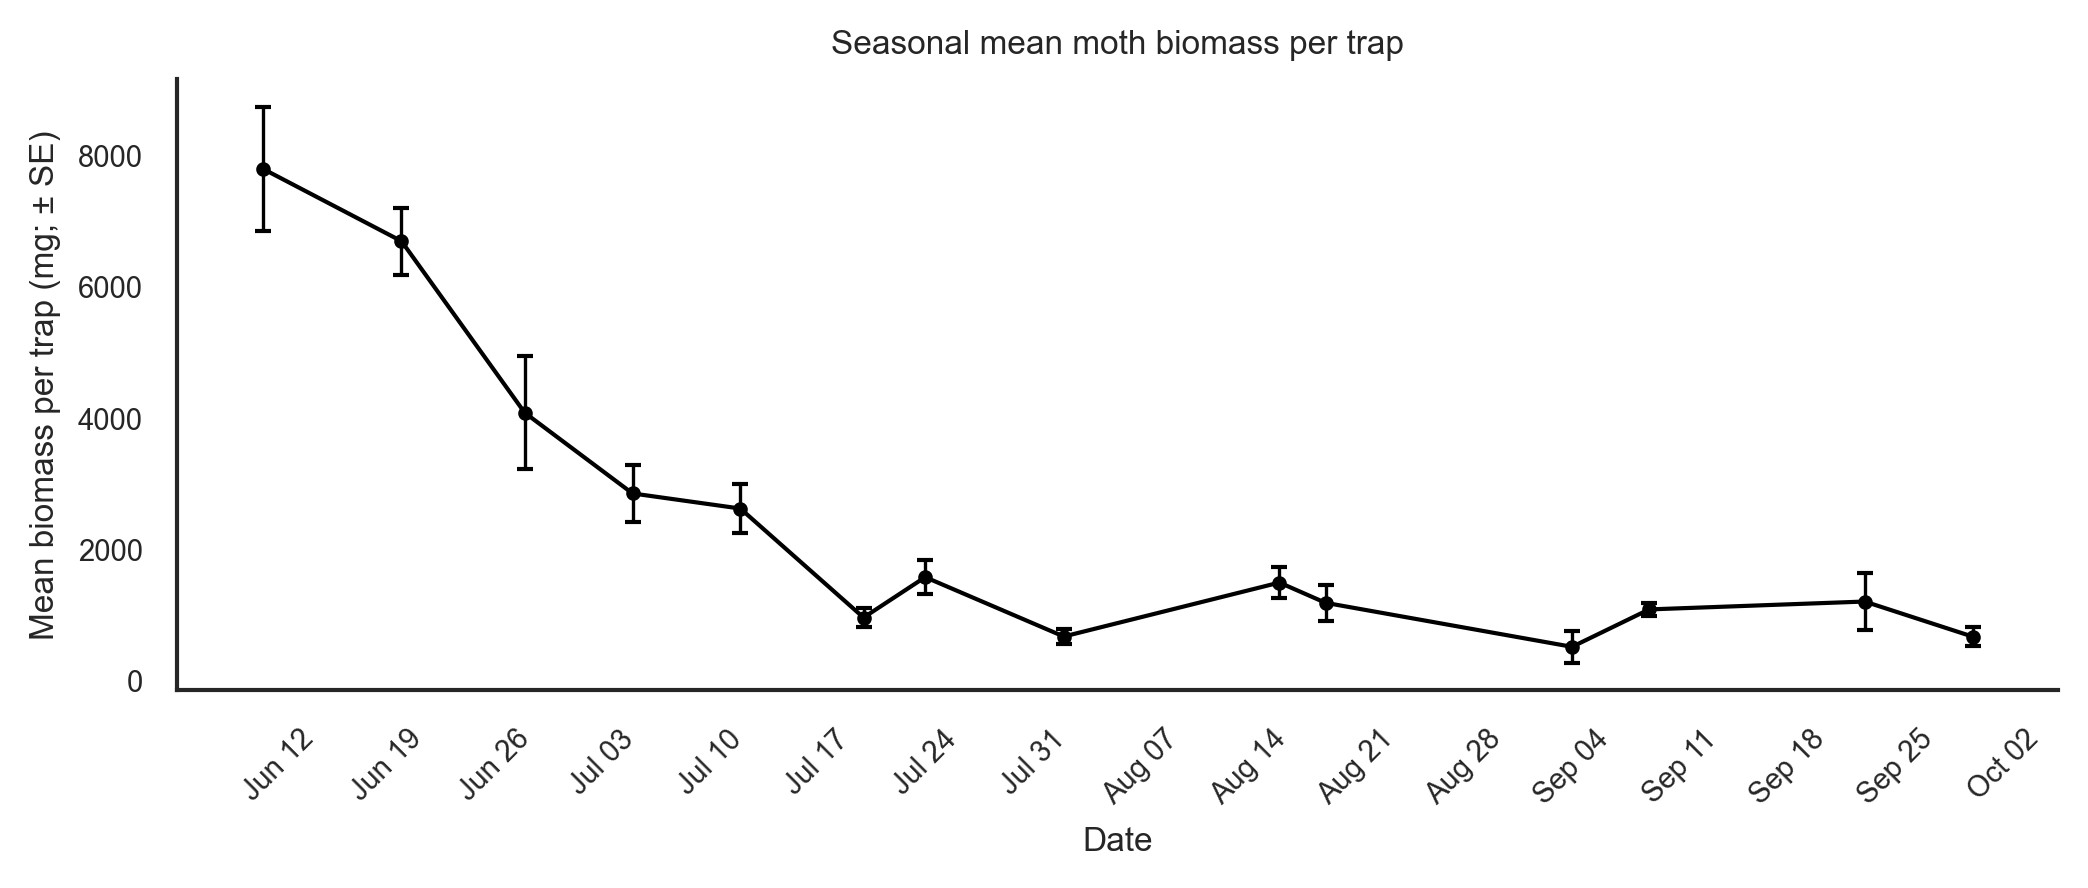

In [ ]:
from scipy.stats import t

bio_fig = combined[["night.mmdd", "site", "bm_total"]].copy()

bio_fig["night.mmdd"] = pd.to_datetime(
    YEAR + bio_fig["night.mmdd"].astype(str).str.zfill(4),
    format="%Y%m%d"
)

sns.set_theme(
    style="white",
    context="paper",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    }
)

d = (
    bio_fig
    .groupby("night.mmdd")["bm_total"]
    .agg(mean="mean", sd="std", n="count")
    .reset_index()
    .sort_values("night.mmdd")
)

# d["ci"] = t.ppf(0.975, d["n"] - 1) * d["sd"] / np.sqrt(d["n"])
# d["ci"] = d["ci"].fillna(0)
d["se"] = d["sd"] / np.sqrt(d["n"])
d["se"] = d["se"].fillna(0)


fig, ax = plt.subplots(figsize=(7, 3), dpi=300)

ax.errorbar(
    d["night.mmdd"],
    d["mean"],
    yerr=d["se"],
    marker="o",
    linestyle="-",
    color="black",
    capsize=2,
    linewidth=1,
    markersize=2.5,
    elinewidth=0.8,
)

# ax.set_xlabel("Date")
# ax.set_ylabel("Mean biomass per trap (mg)")
# ax.set_title("Seasonal mean biomass per trap")

ax.set_ylabel("Mean biomass per trap (mg; ± SE)")
# ax.set_xlabel("Date")
# ax.set_title("Seasonal mean moth biomass per trap")


locator = mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
formatter = mdates.DateFormatter("%b %d")
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

for lbl in ax.get_xticklabels():
    lbl.set_rotation(90)

ax.grid(False)
plt.tight_layout()
plt.show()


**PLEASE FIND BELOW THE INDIVUAL COUNT AND SIZE DISTRIBUTIONS FOR EACH SITE IN THE YEAR 2023**

In [175]:
merged, img_agg, night_agg = runtrends("2023", "WS1")

In [177]:
merged.to_csv("/Users/suhavi./Projects/moths/The Project/Results/InferencePipeline/WS1_2023_sizeclass_predictions.csv")

/var/folders/lk/4ww6x1f517q8csj76p8gdj8m0000gn/T/ipykernel_67784/1348276710.py:5: RuntimeWarning: divide by zero encountered in log
  data2= np.log(np.array(data))


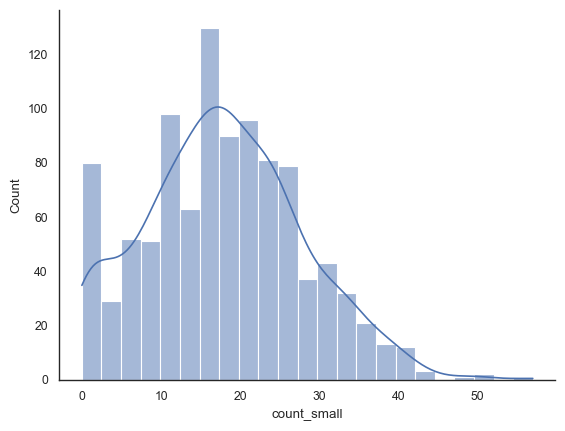

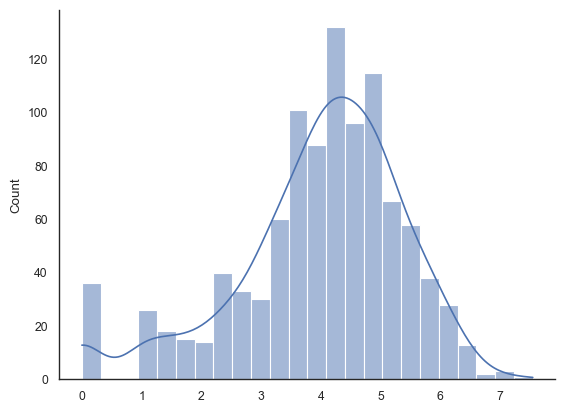

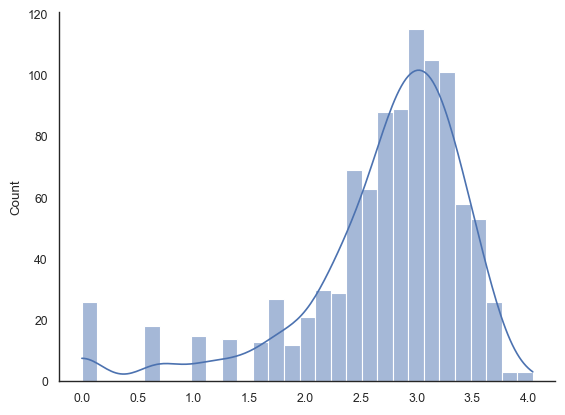

In [169]:
import seaborn as sns
# data = night_agg["count_small"]
data = img_agg["count_small"]
data1 = np.sqrt(np.array(data))
data2= np.log(np.array(data))
import matplotlib.pyplot as plt
sns.histplot(data, kde=True)
plt.show()

sns.histplot(data1, kde=True)
plt.show()

sns.histplot(data2, kde=True)
plt.show()

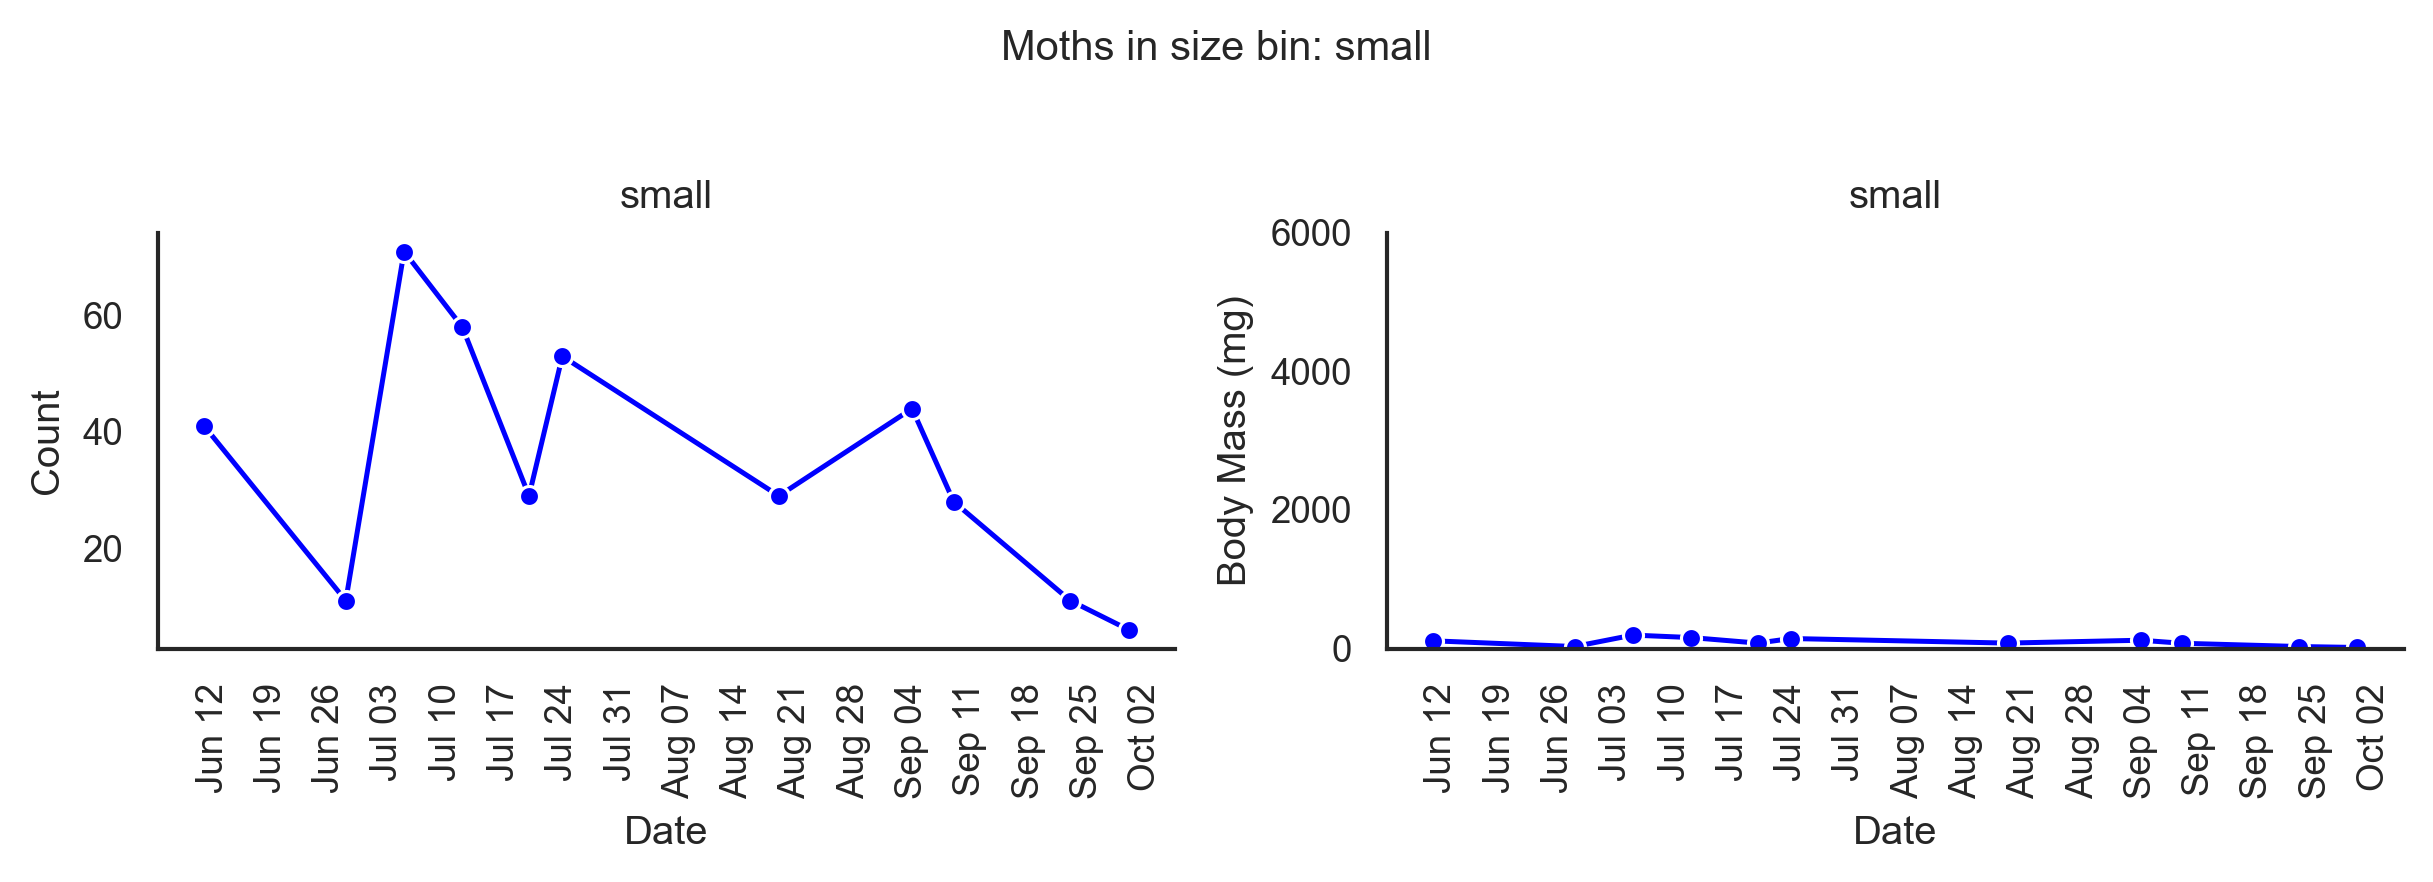

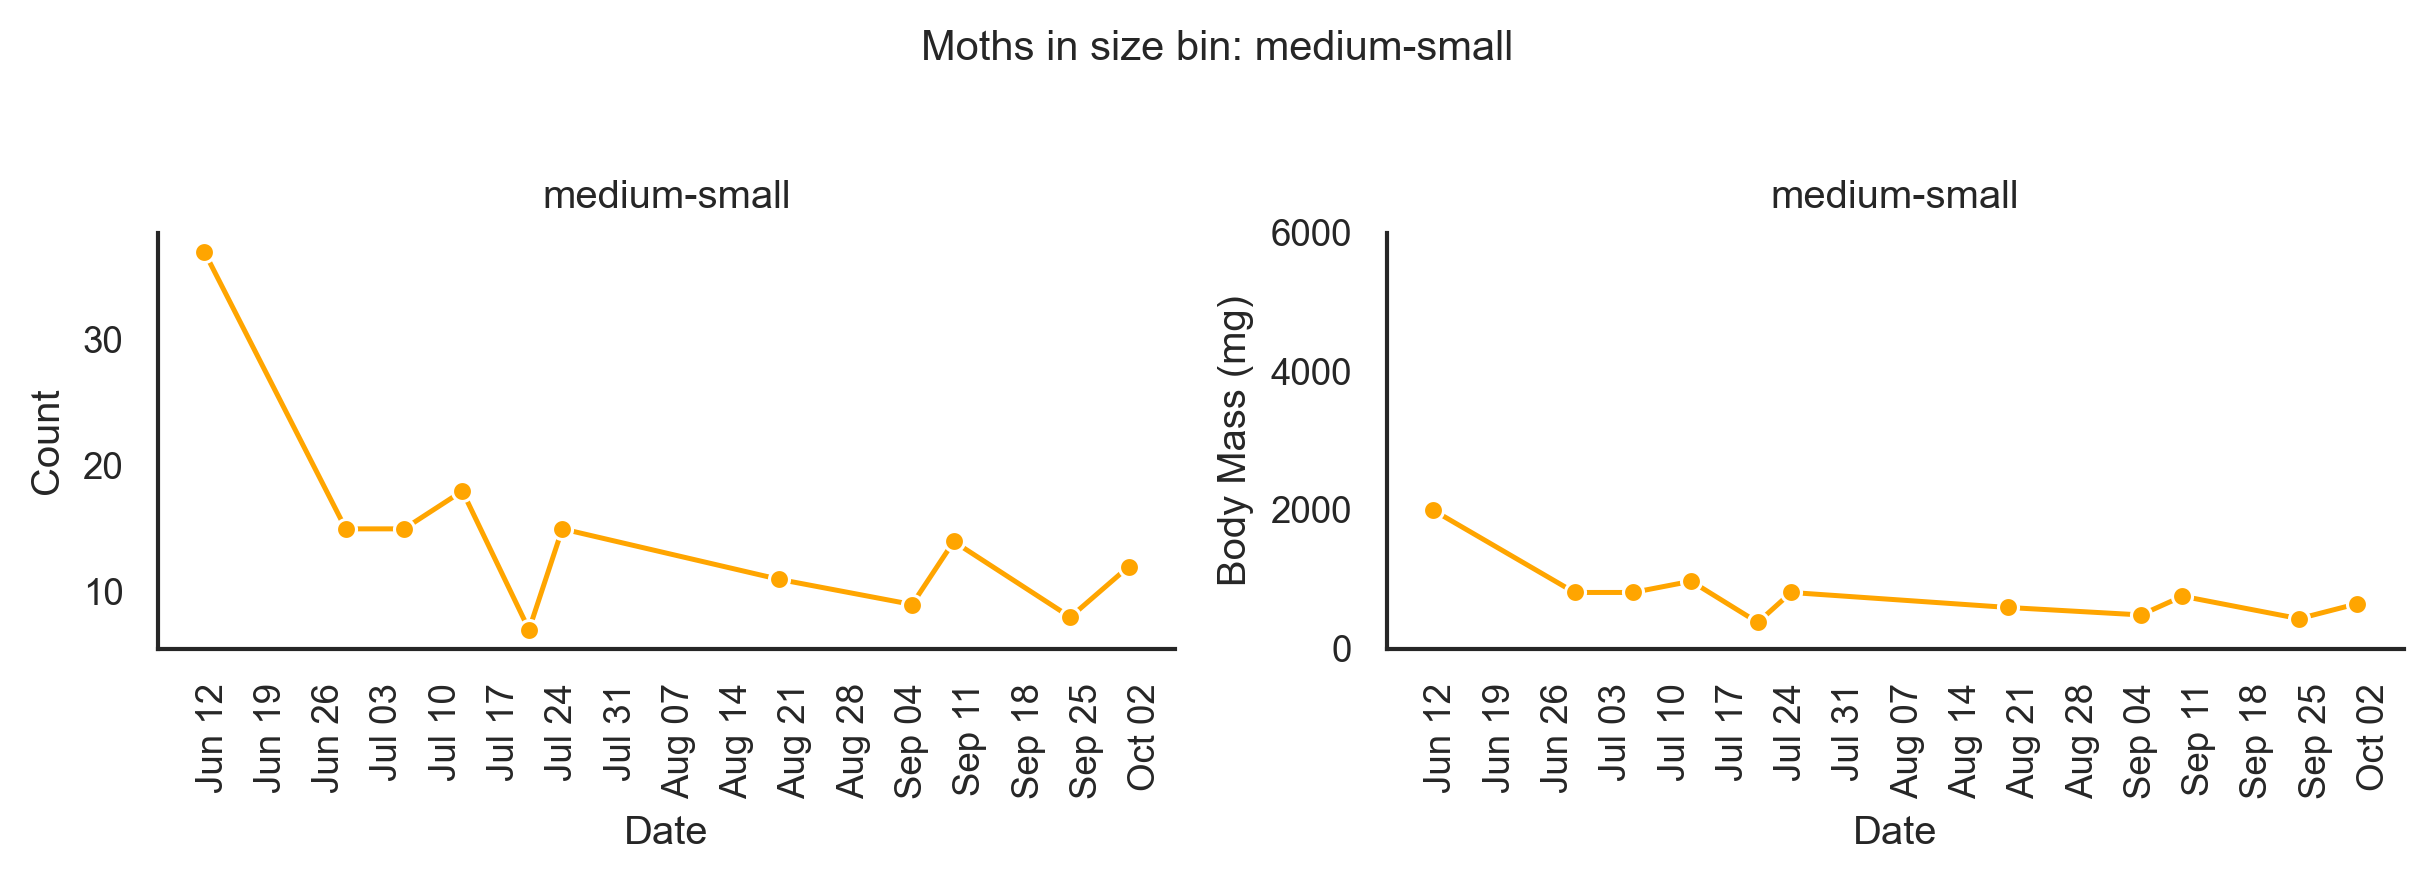

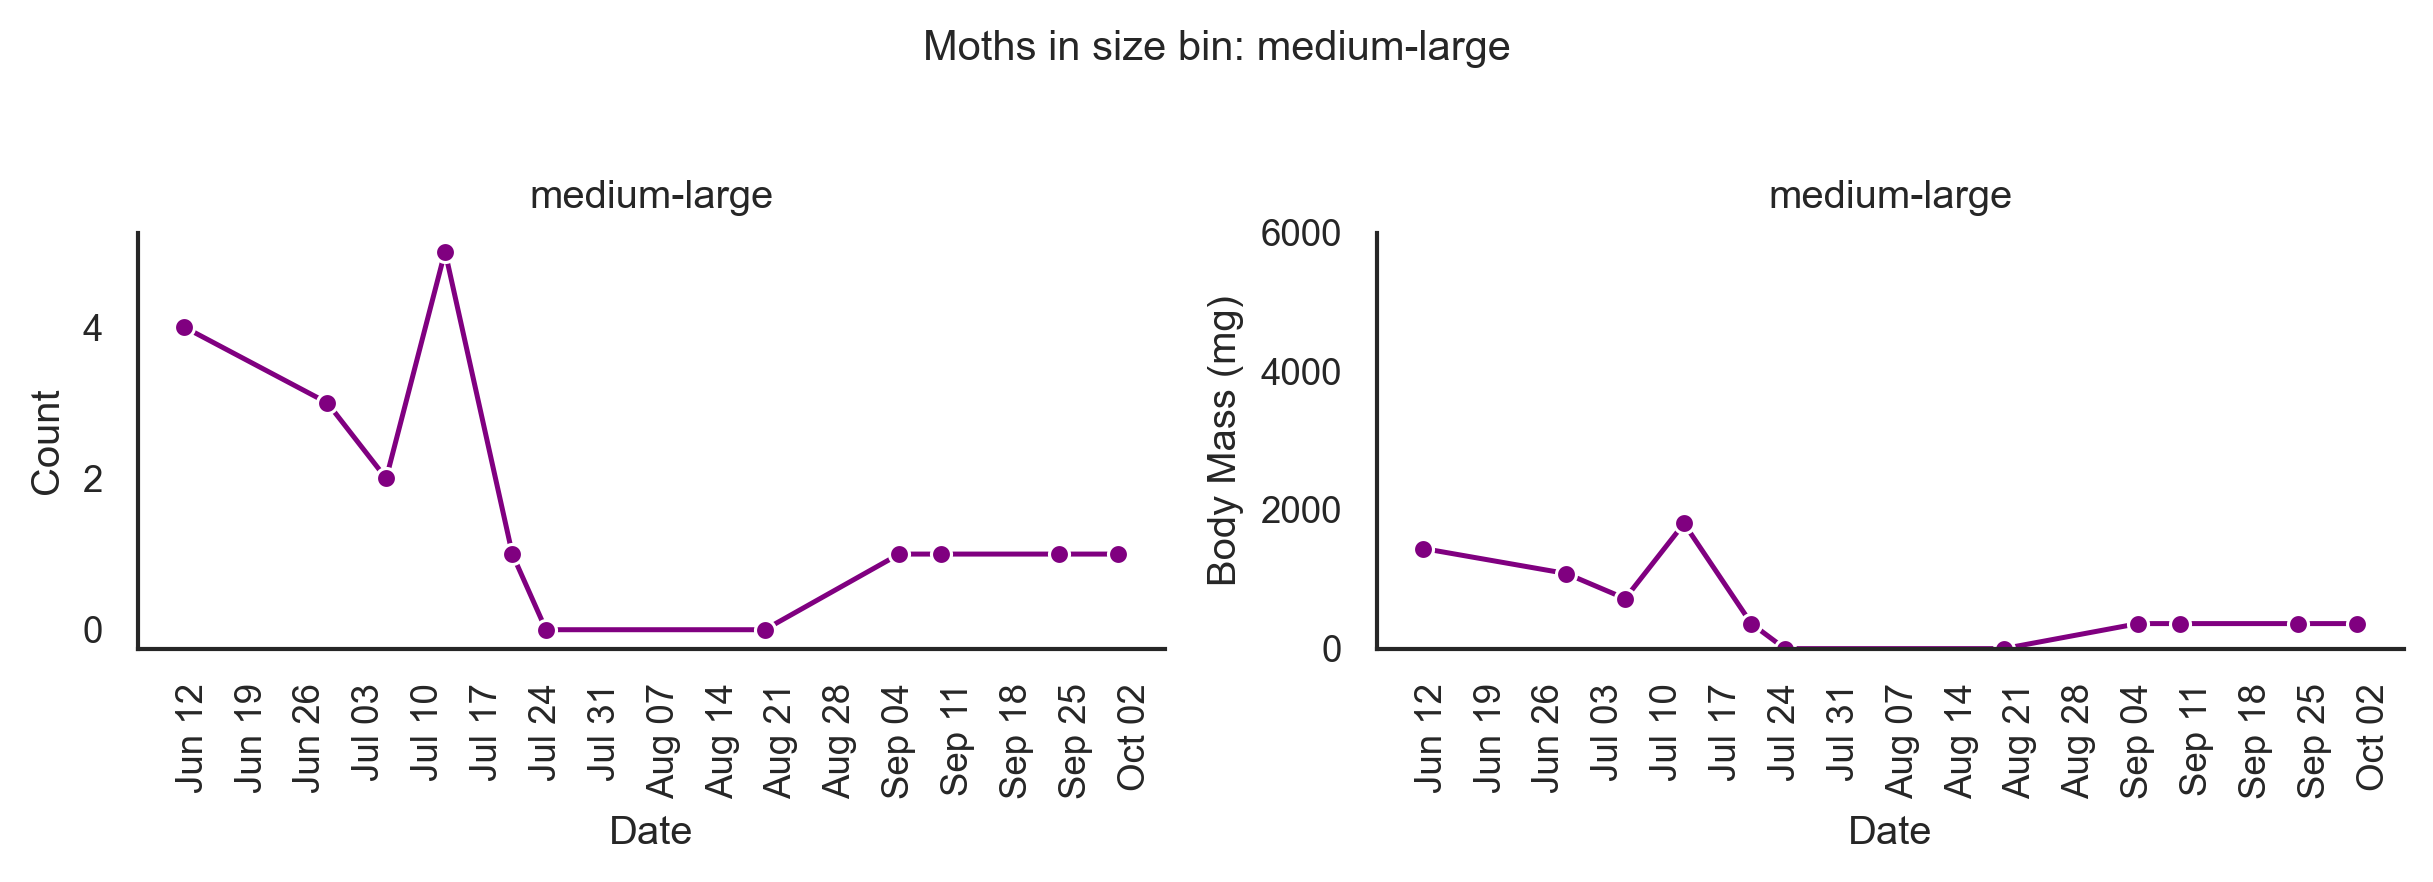

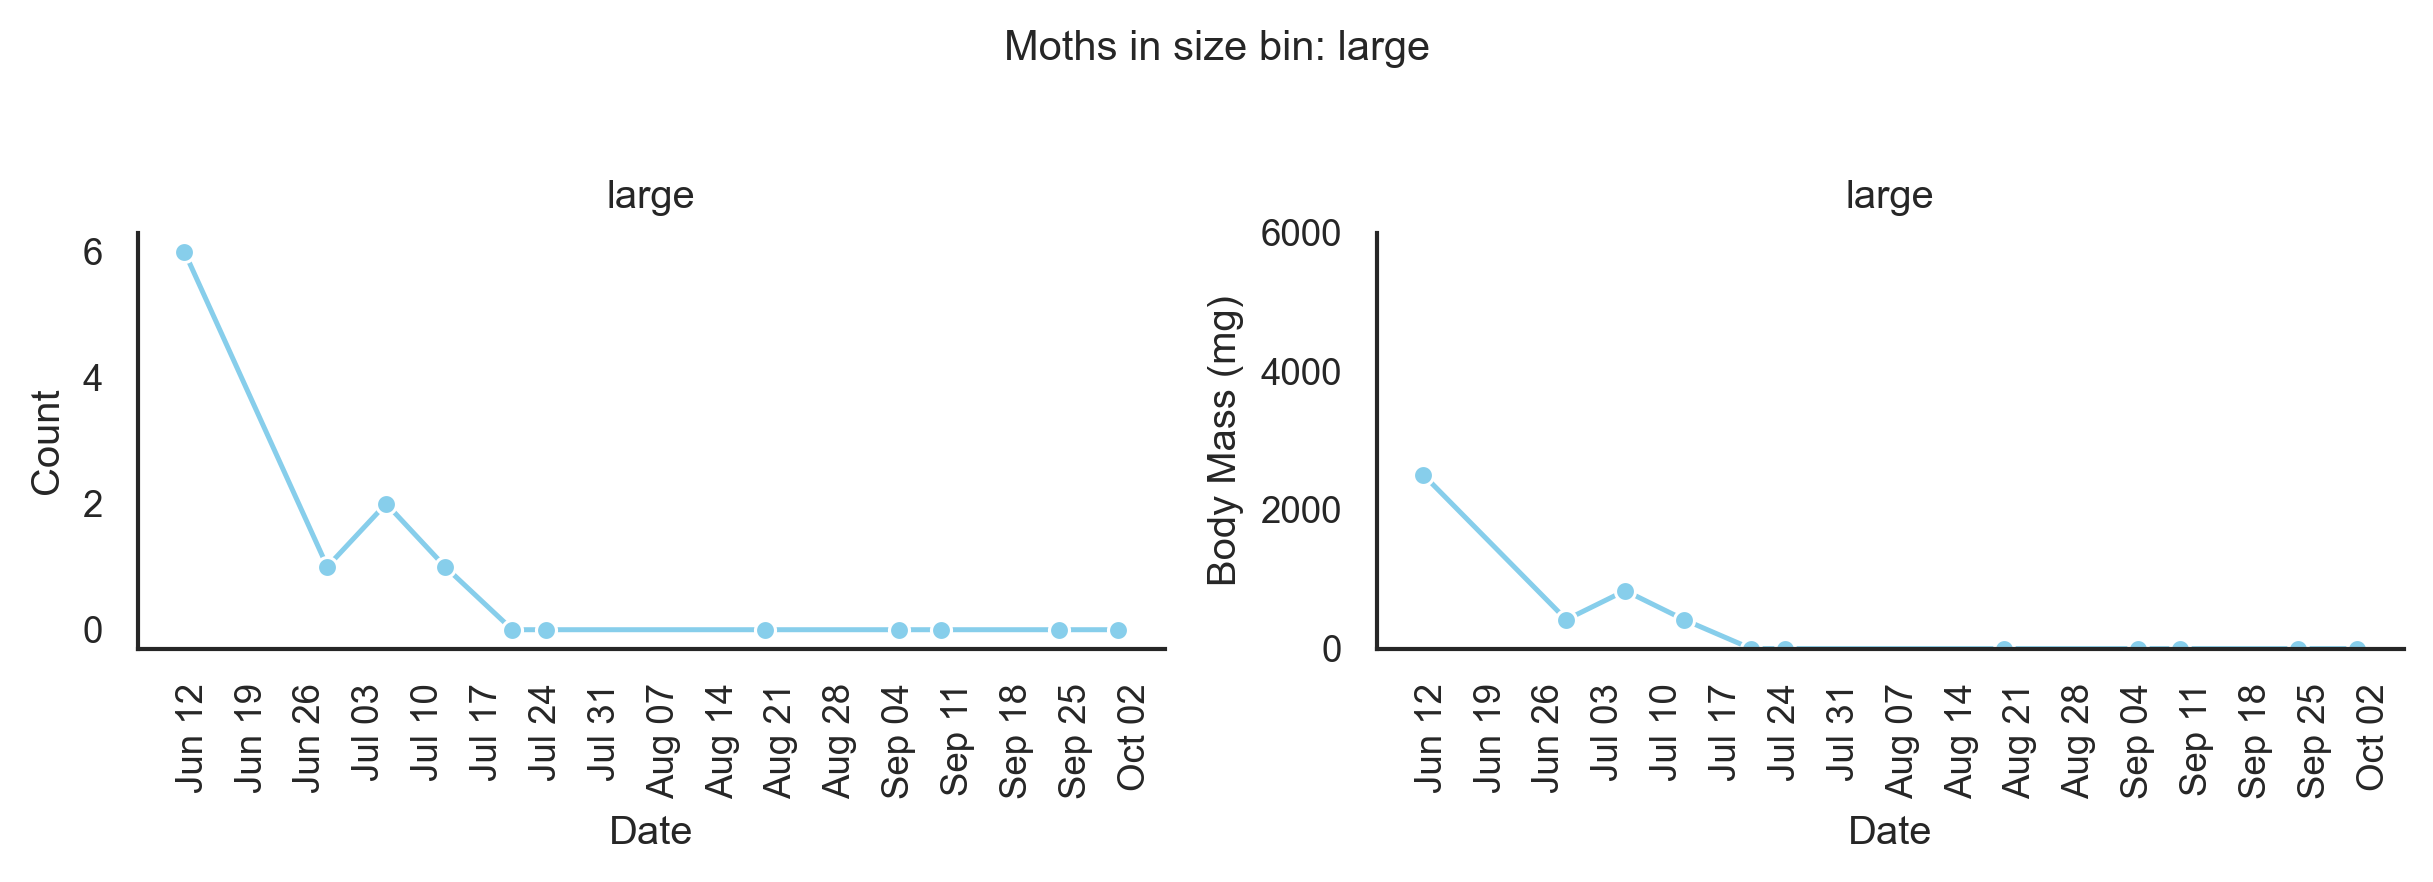

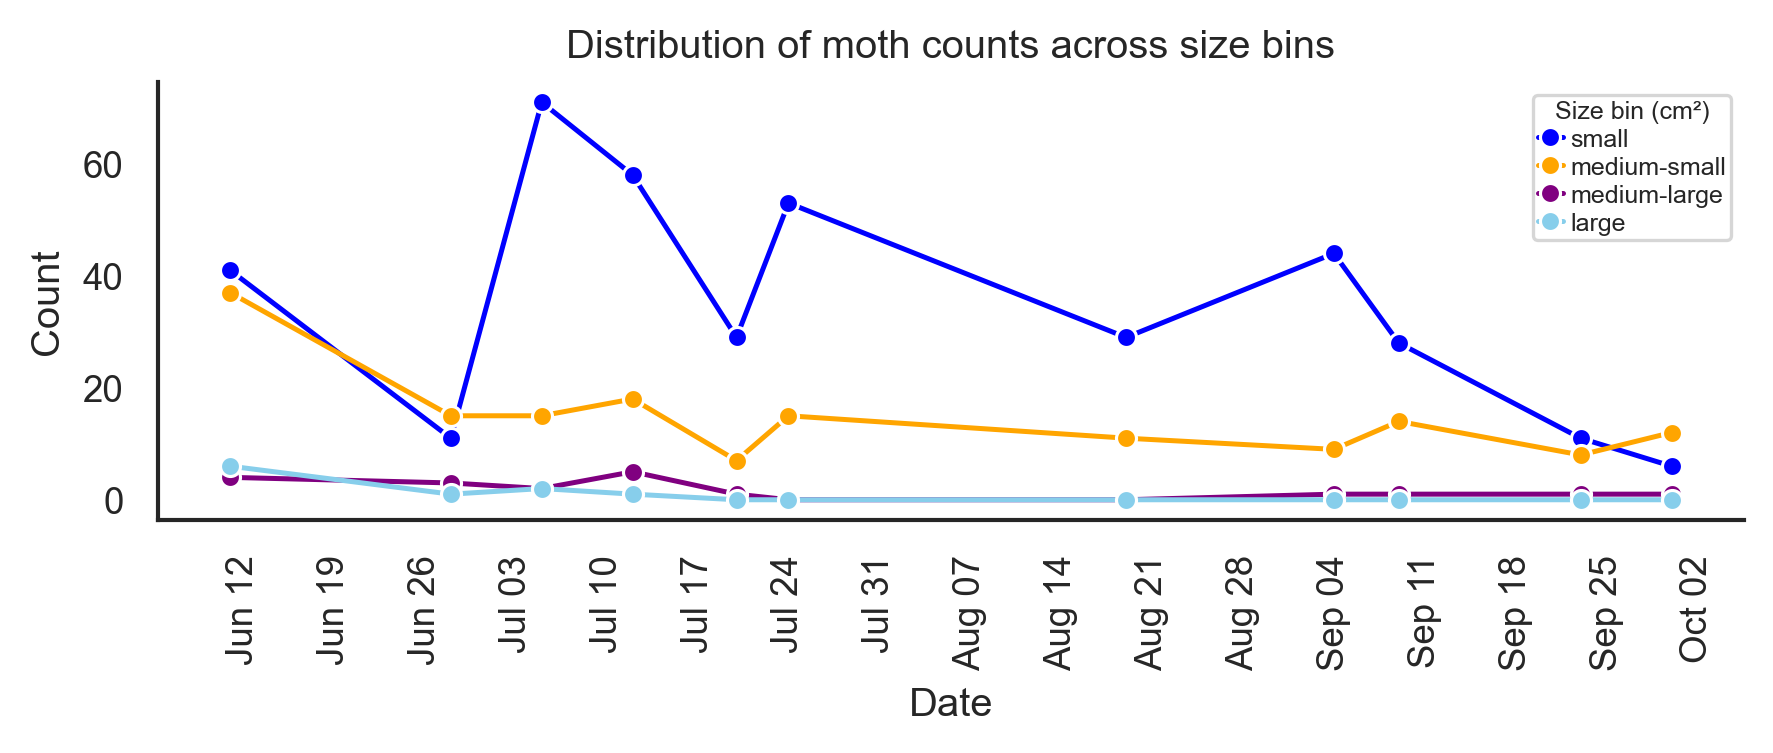

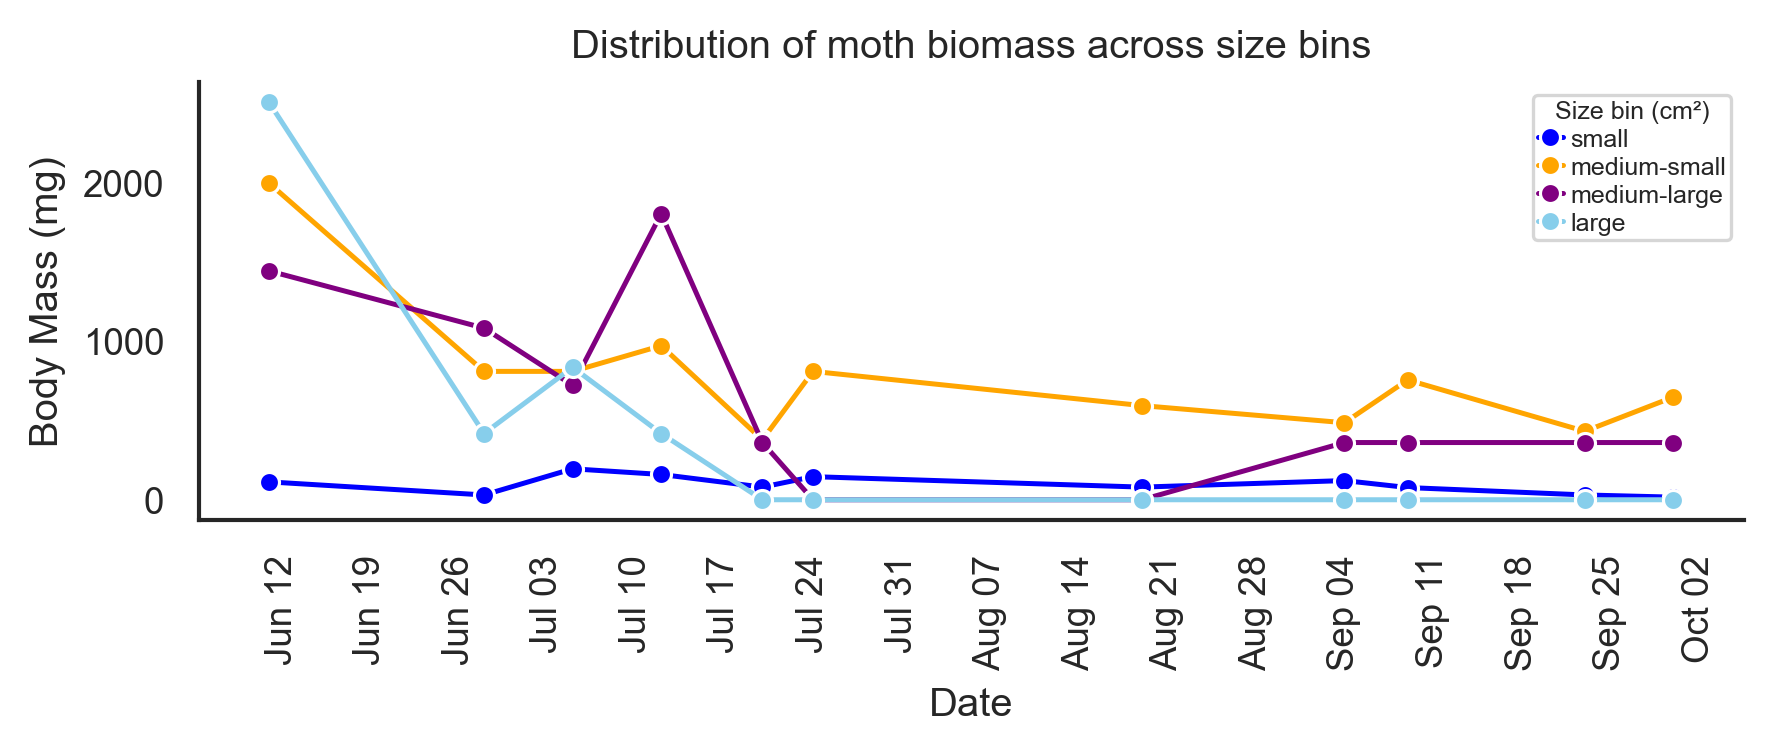

(                             filePath_pred                         fileName  \
 26090  WS4/2023_WS4_0611_0130_WSCT3795.JPG  2023_WS4_0611_0130_WSCT3795.JPG   
 14335  WS4/2023_WS4_0611_2300_WSCT3765.JPG  2023_WS4_0611_2300_WSCT3765.JPG   
 14336  WS4/2023_WS4_0611_2300_WSCT3765.JPG  2023_WS4_0611_2300_WSCT3765.JPG   
 14337  WS4/2023_WS4_0611_2300_WSCT3765.JPG  2023_WS4_0611_2300_WSCT3765.JPG   
 14338  WS4/2023_WS4_0611_2300_WSCT3765.JPG  2023_WS4_0611_2300_WSCT3765.JPG   
 ...                                    ...                              ...   
 21706  WS4/2023_WS4_0930_2225_WSCT4997.JPG  2023_WS4_0930_2225_WSCT4997.JPG   
 21705  WS4/2023_WS4_0930_2225_WSCT4997.JPG  2023_WS4_0930_2225_WSCT4997.JPG   
 6551   WS4/2023_WS4_0930_0345_WSCT5061.JPG  2023_WS4_0930_0345_WSCT5061.JPG   
 24927  WS4/2023_WS4_0930_0250_WSCT5050.JPG  2023_WS4_0930_0250_WSCT5050.JPG   
 21483  WS4/2023_WS4_0930_0235_WSCT5047.JPG  2023_WS4_0930_0235_WSCT5047.JPG   
 
        year_pred site_pred        X_M

In [129]:
runtrends("2023", "WS4")

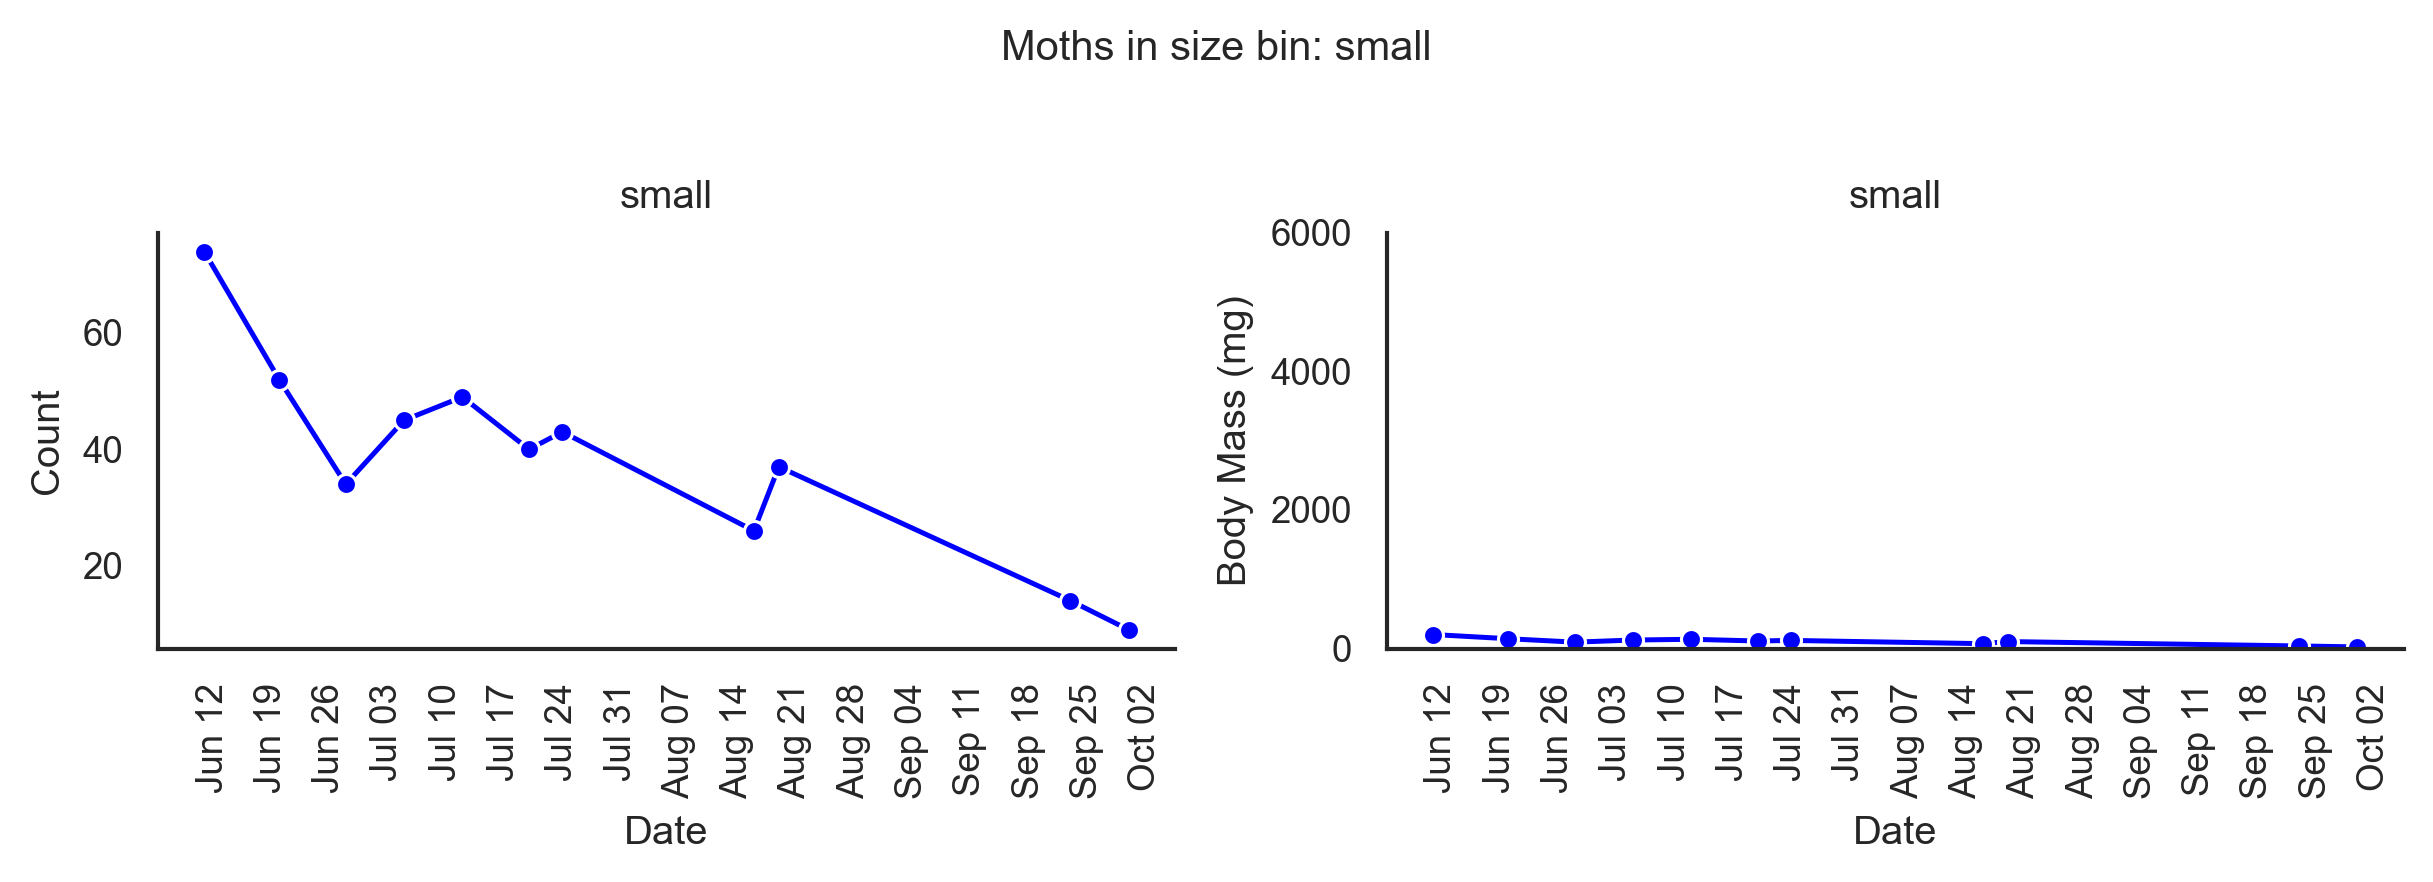

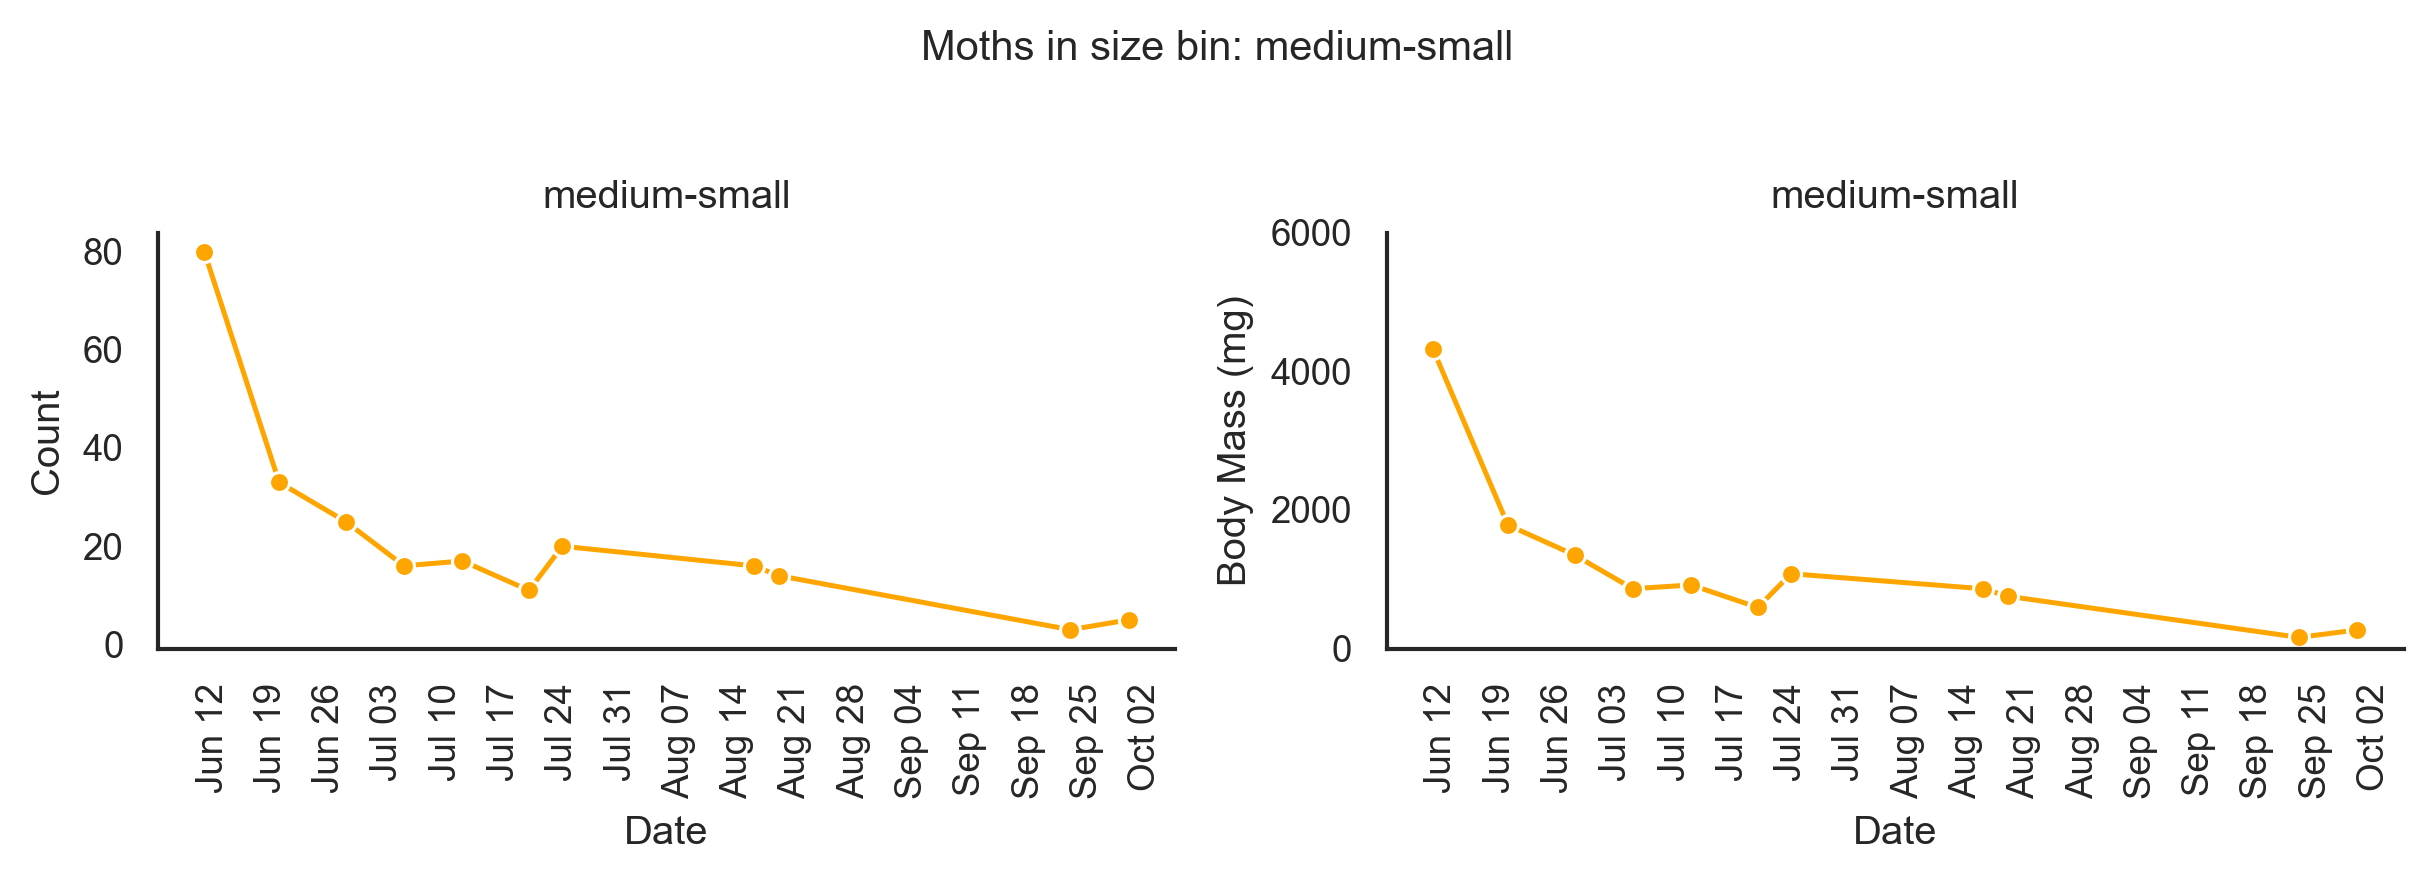

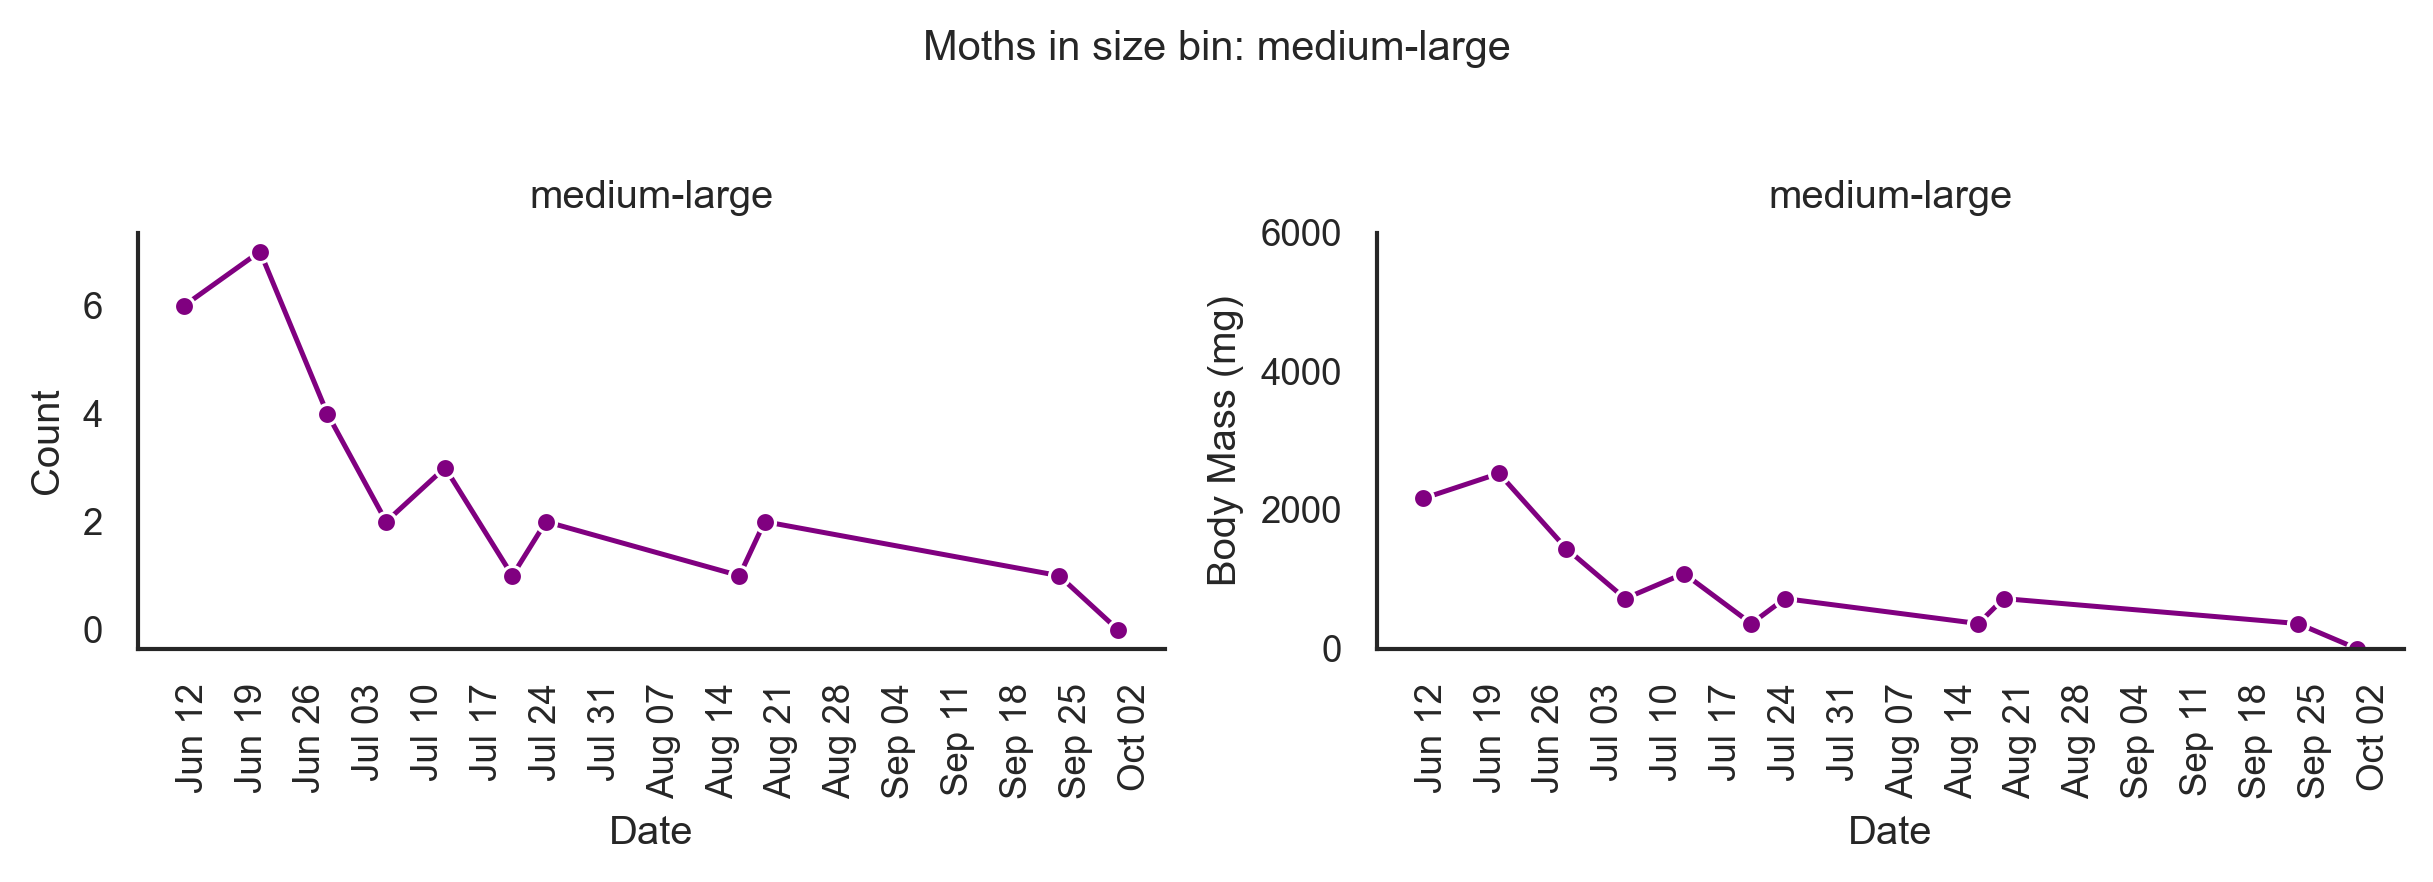

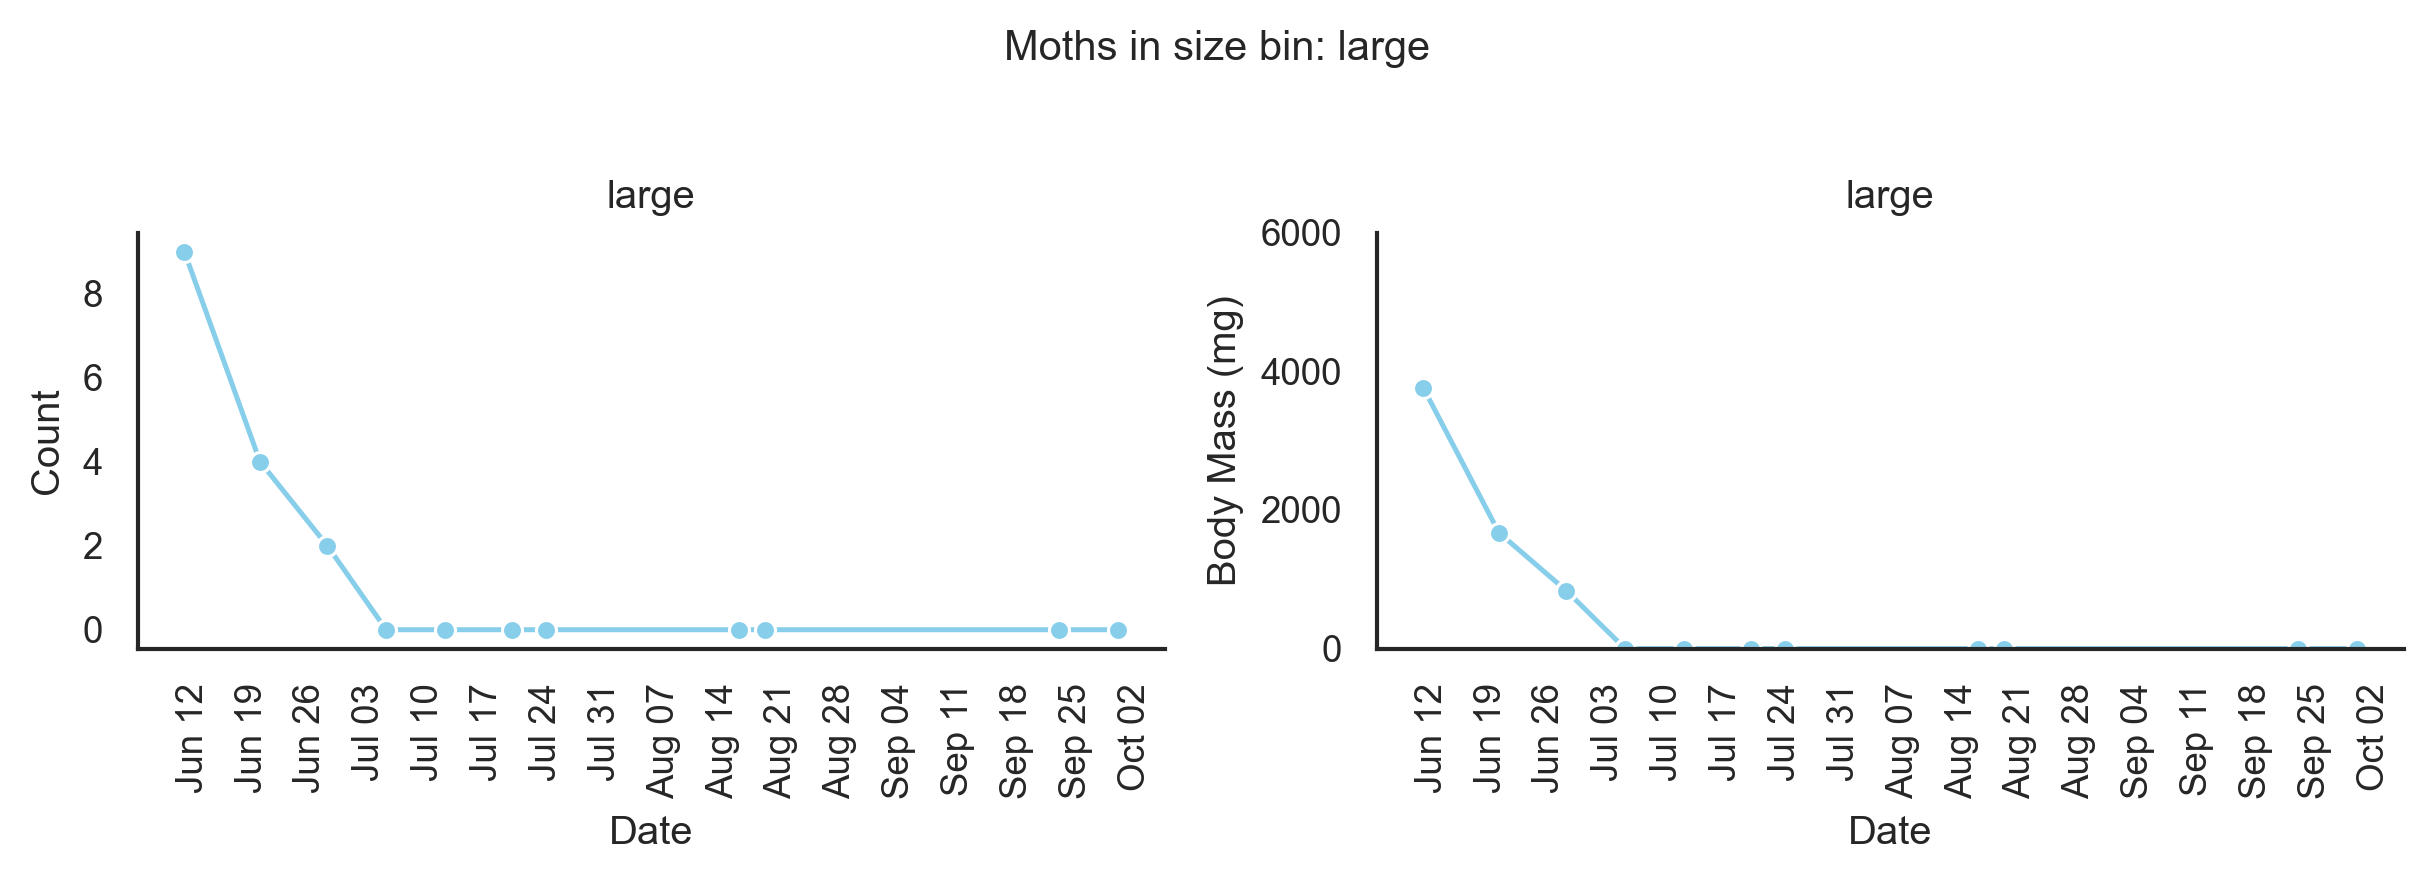

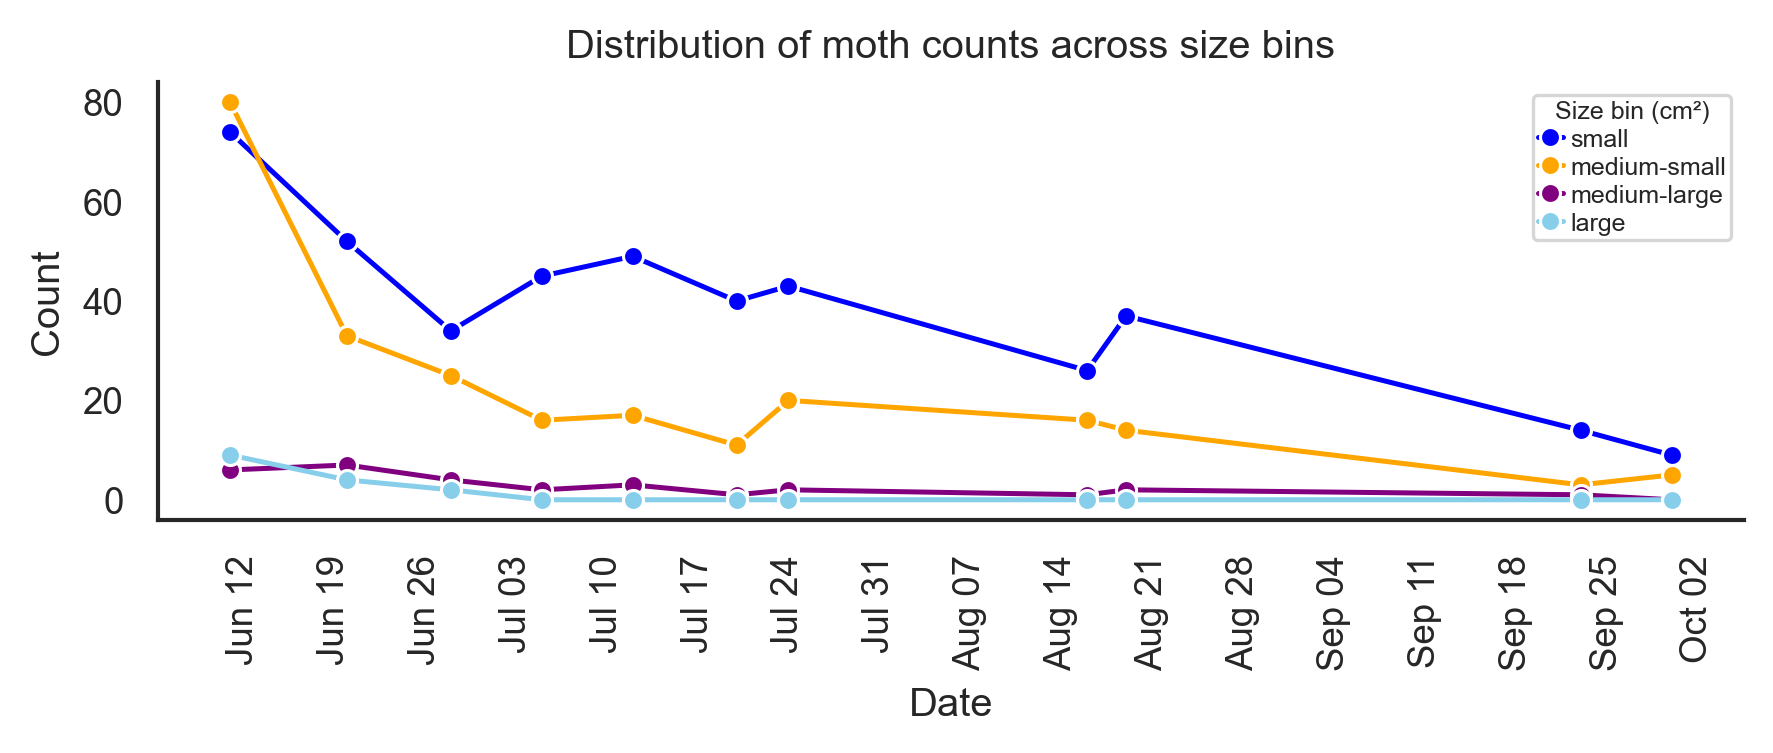

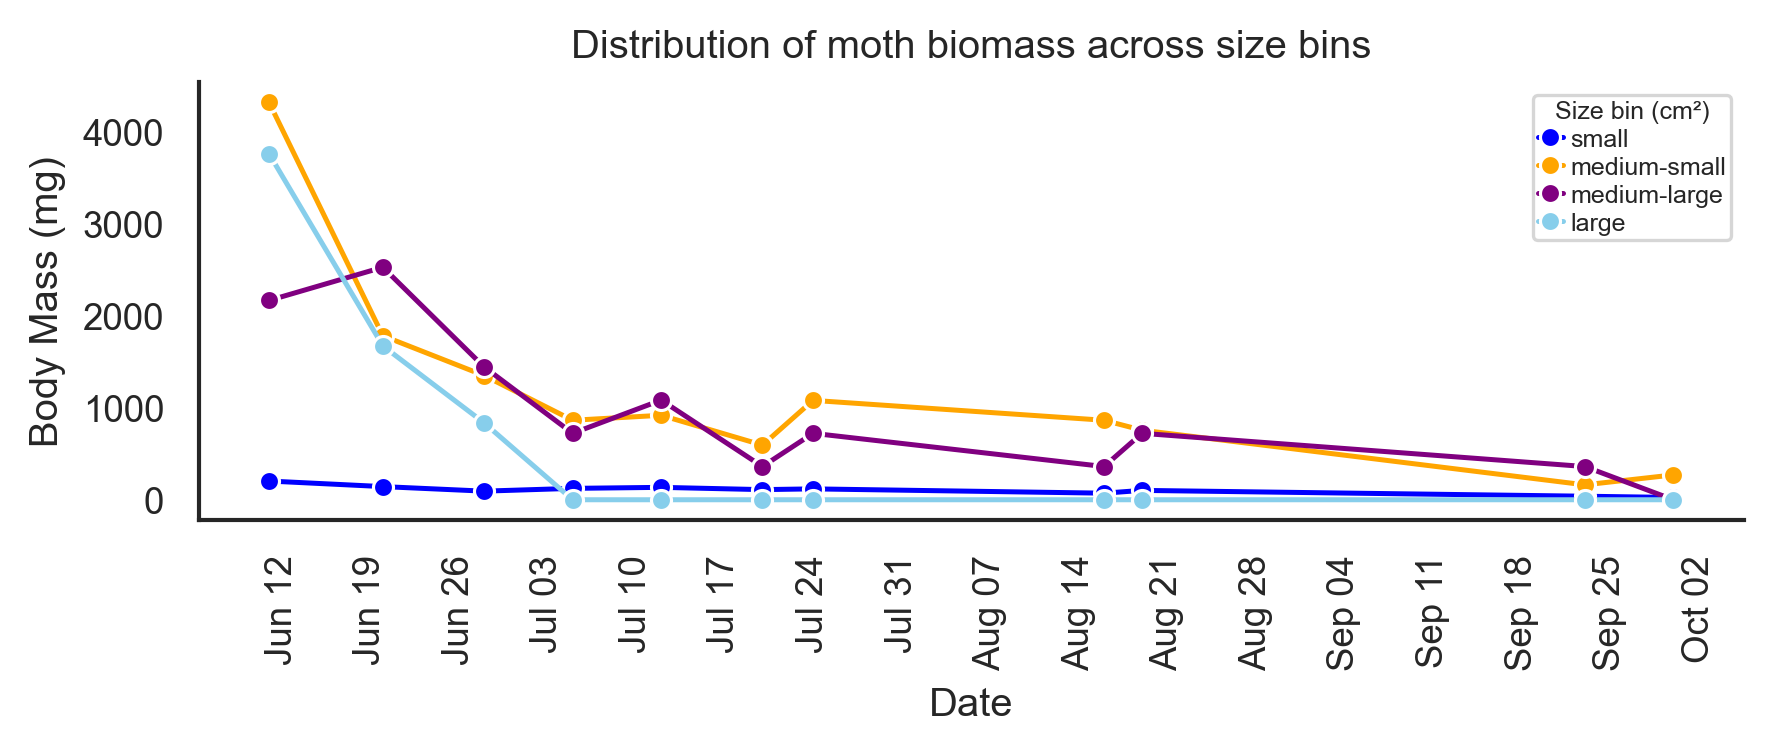

(                             filePath_pred                         fileName  \
 16558  WS5/2023_WS5_0611_2345_WSCT6111.JPG  2023_WS5_0611_2345_WSCT6111.JPG   
 7455   WS5/2023_WS5_0611_0300_WSCT6150.JPG  2023_WS5_0611_0300_WSCT6150.JPG   
 7456   WS5/2023_WS5_0611_0300_WSCT6150.JPG  2023_WS5_0611_0300_WSCT6150.JPG   
 7457   WS5/2023_WS5_0611_0300_WSCT6150.JPG  2023_WS5_0611_0300_WSCT6150.JPG   
 7458   WS5/2023_WS5_0611_0300_WSCT6150.JPG  2023_WS5_0611_0300_WSCT6150.JPG   
 ...                                    ...                              ...   
 27092  WS5/2023_WS5_0930_0030_WSCT7264.JPG  2023_WS5_0930_0030_WSCT7264.JPG   
 27093  WS5/2023_WS5_0930_0030_WSCT7264.JPG  2023_WS5_0930_0030_WSCT7264.JPG   
 27094  WS5/2023_WS5_0930_0030_WSCT7264.JPG  2023_WS5_0930_0030_WSCT7264.JPG   
 27096  WS5/2023_WS5_0930_2220_WSCT7238.JPG  2023_WS5_0930_2220_WSCT7238.JPG   
 335    WS5/2023_WS5_0930_0055_WSCT7269.JPG  2023_WS5_0930_0055_WSCT7269.JPG   
 
        year_pred site_pred        X_M

In [130]:
runtrends("2023", "WS5")

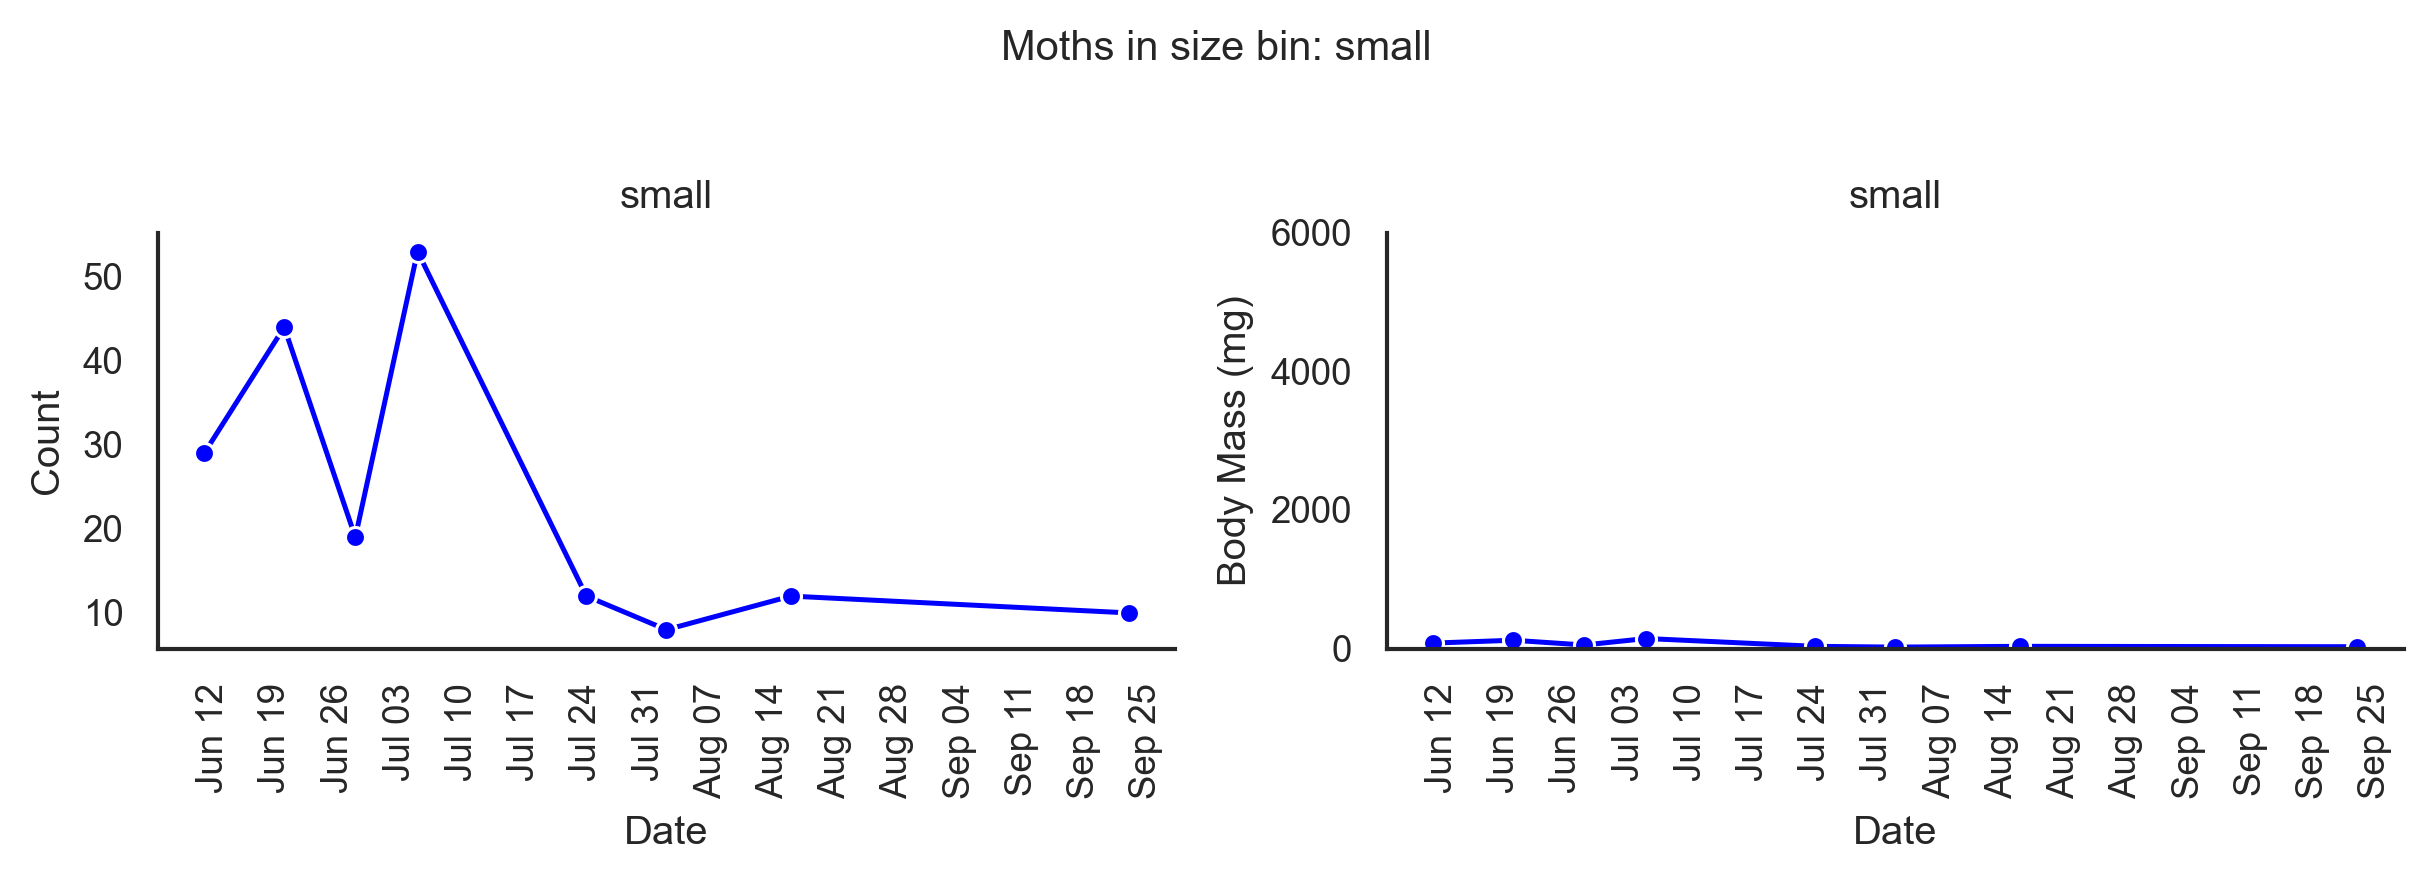

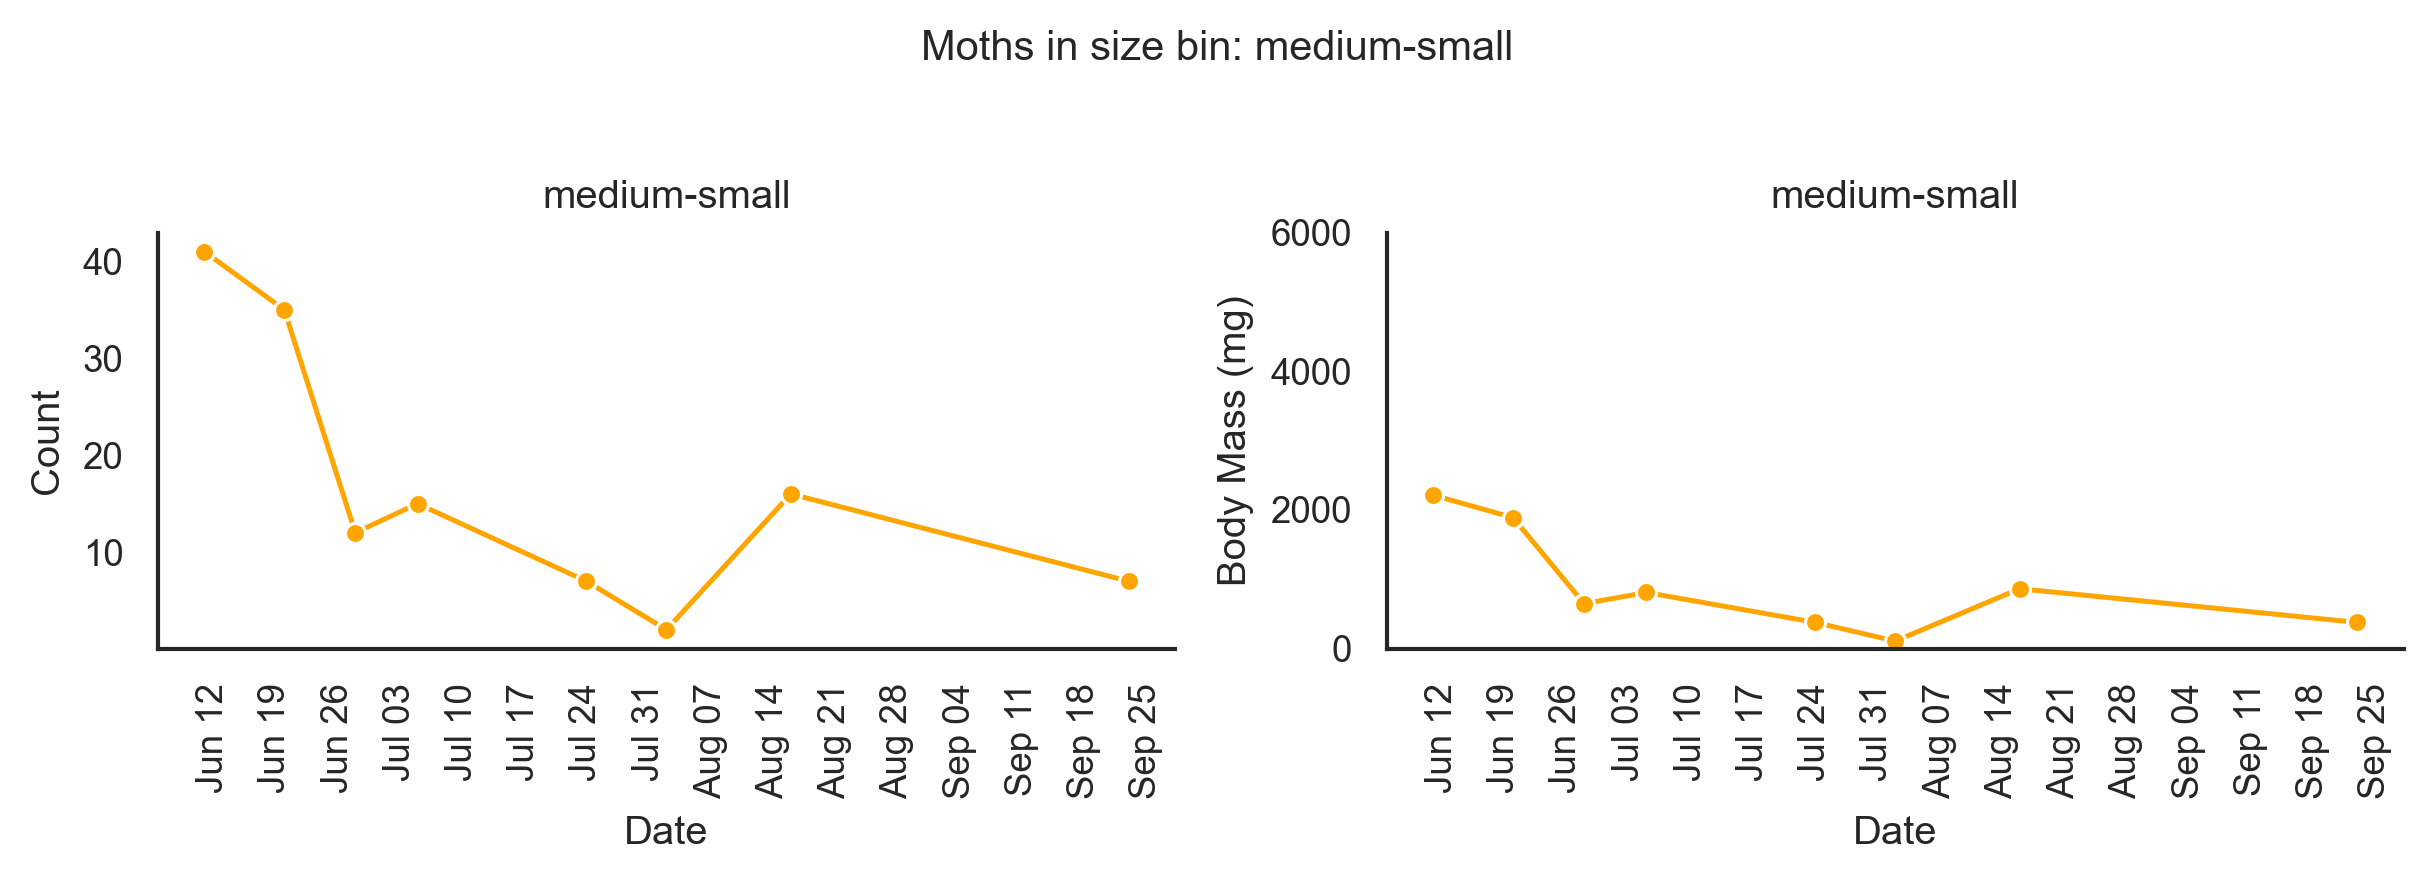

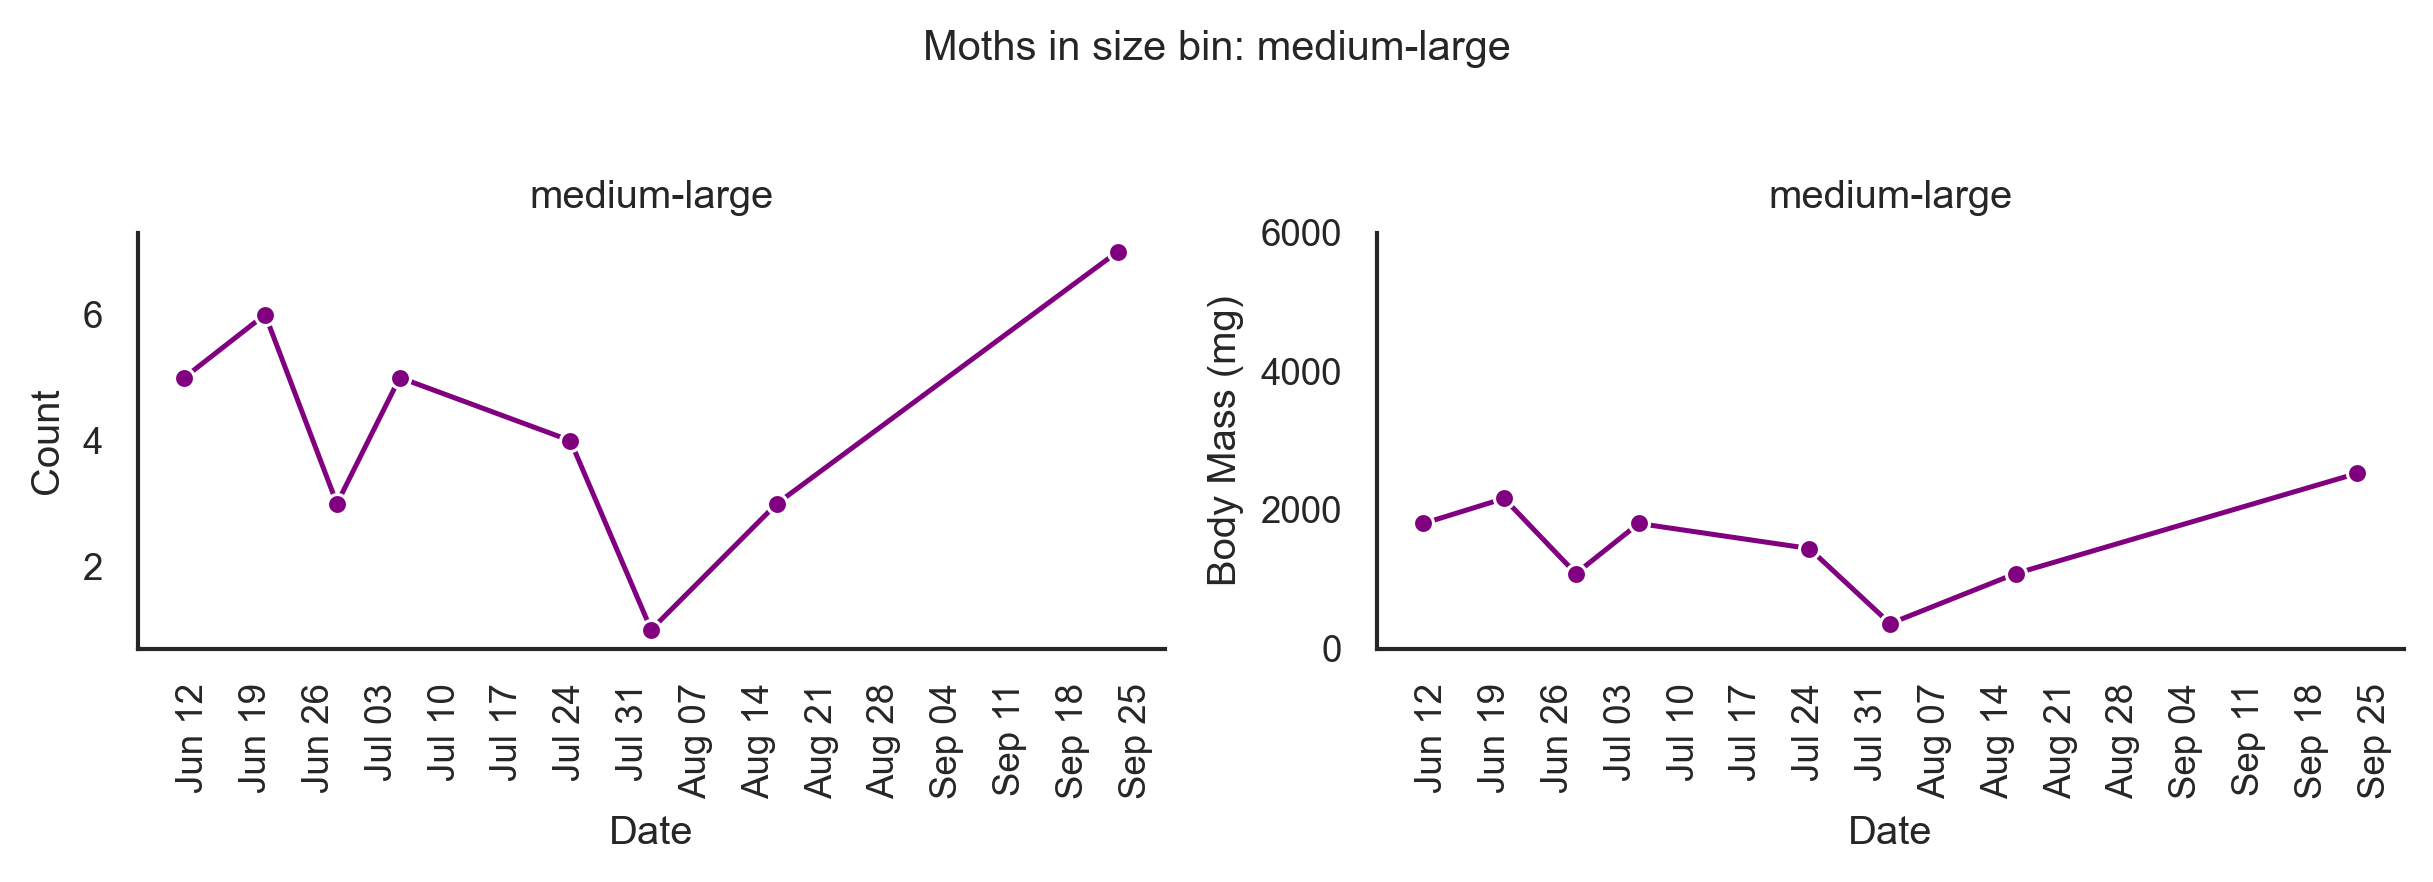

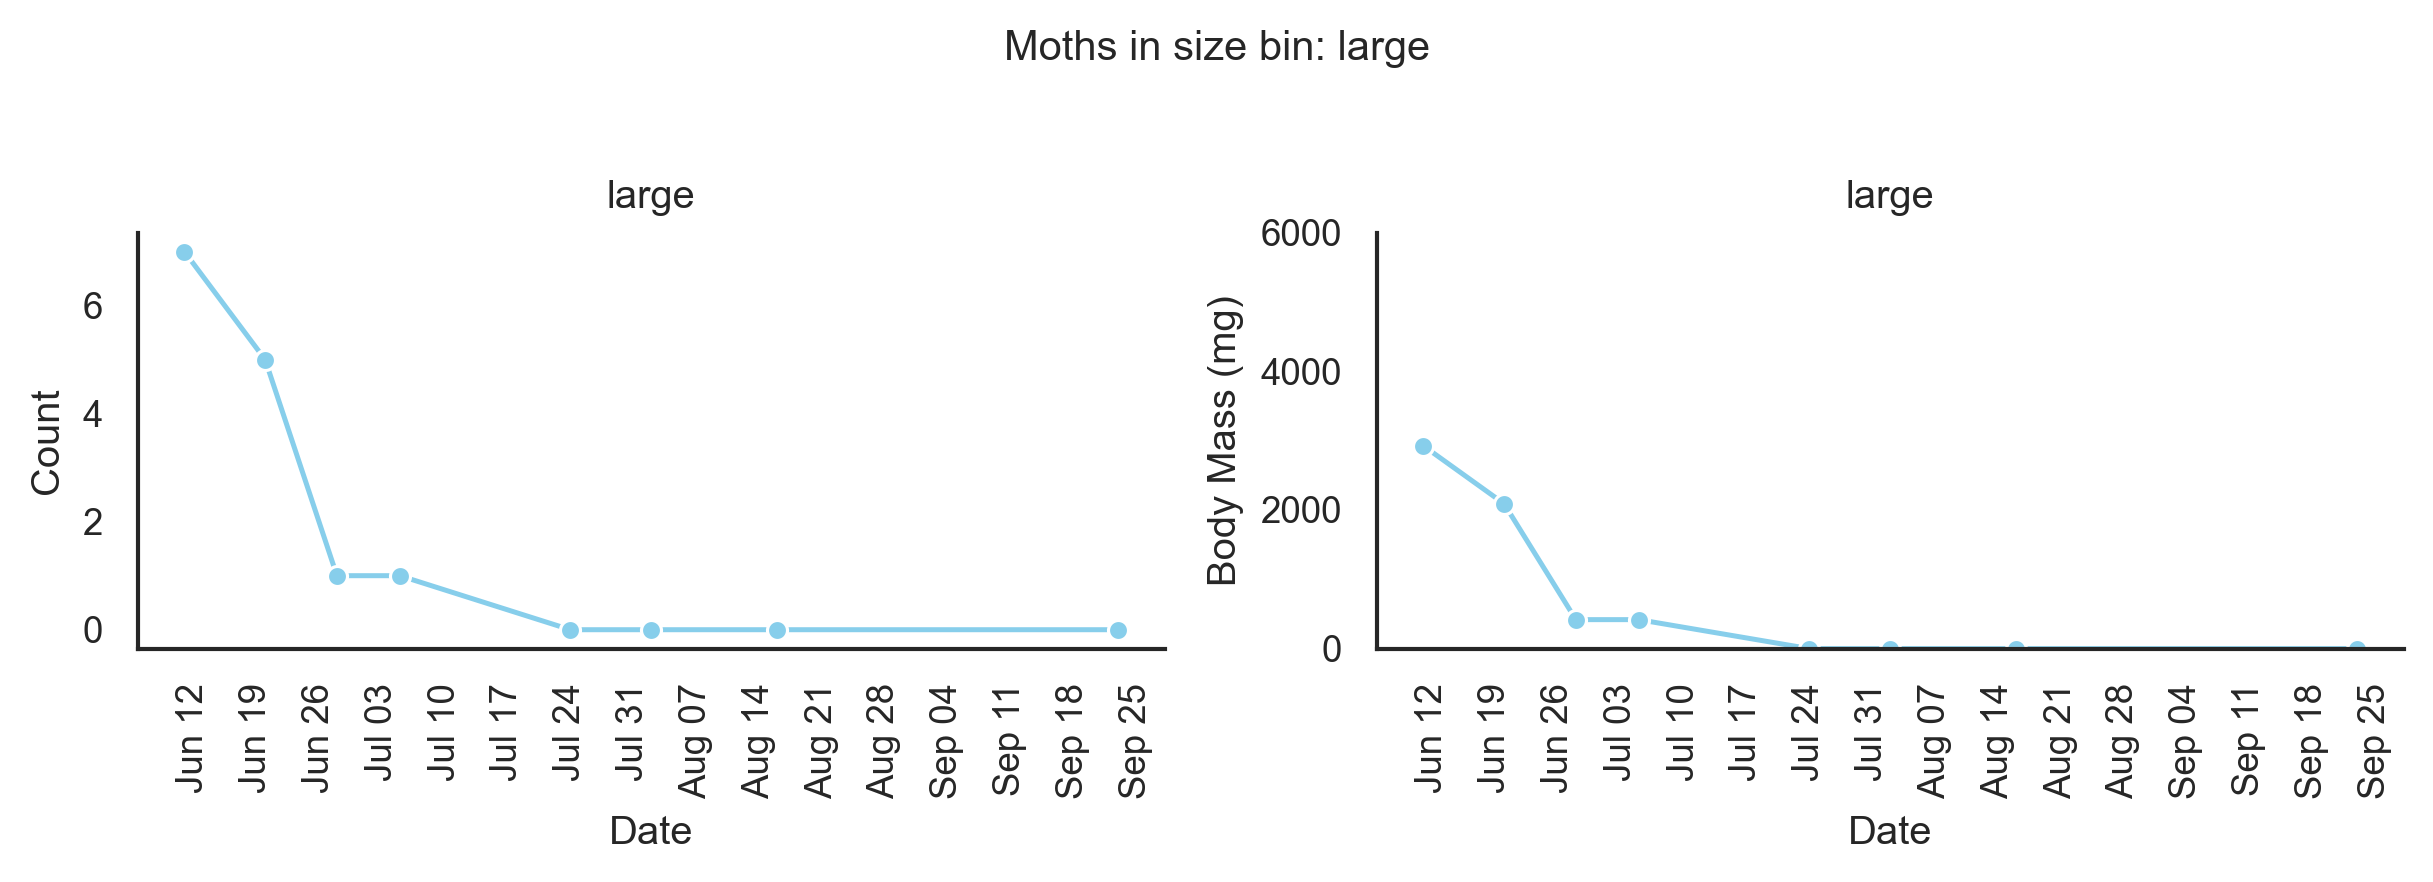

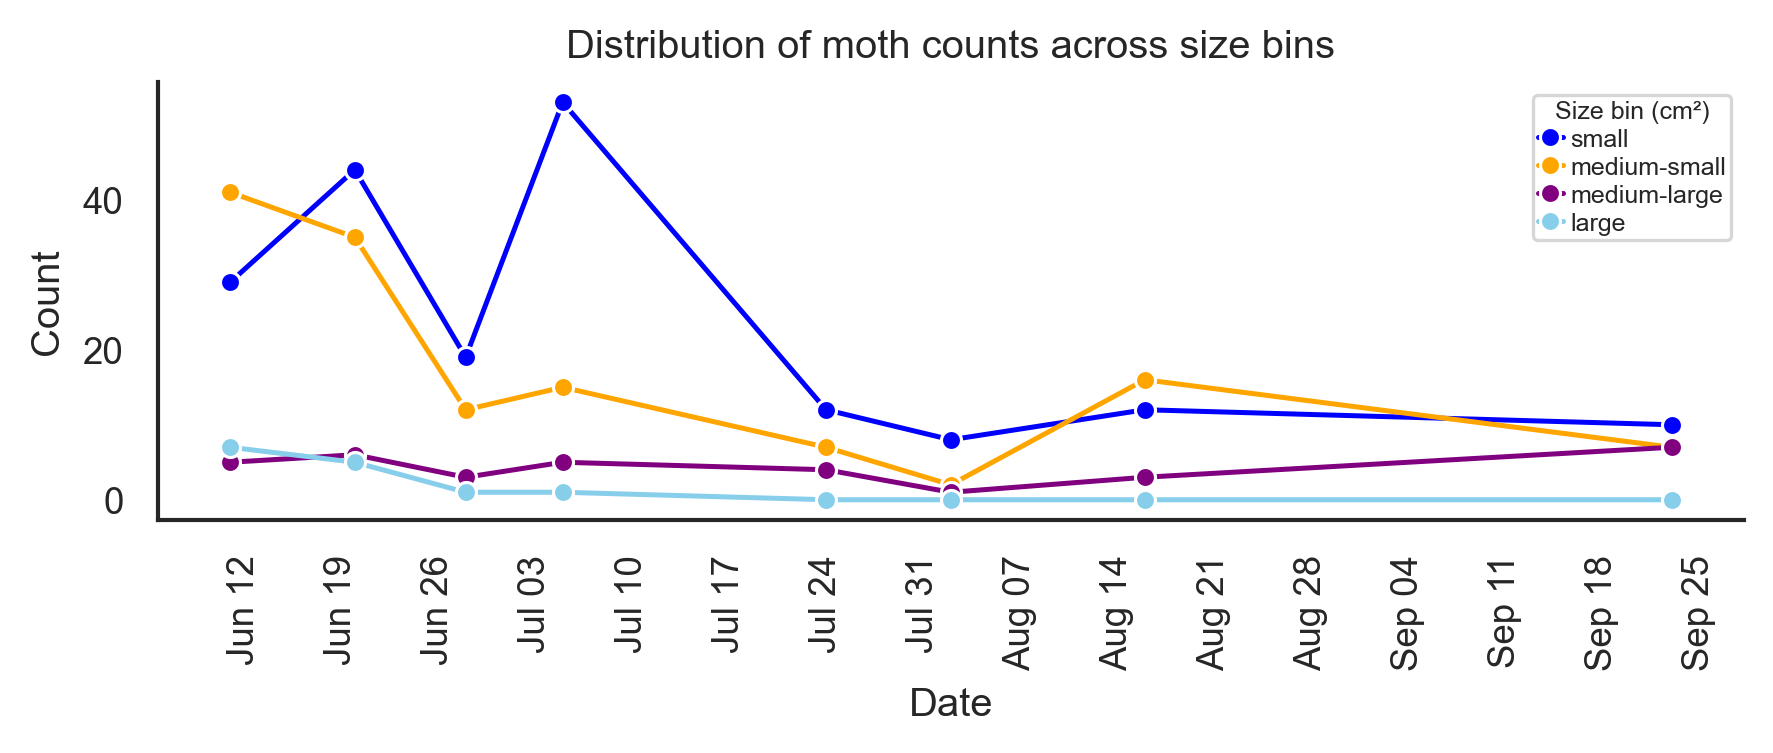

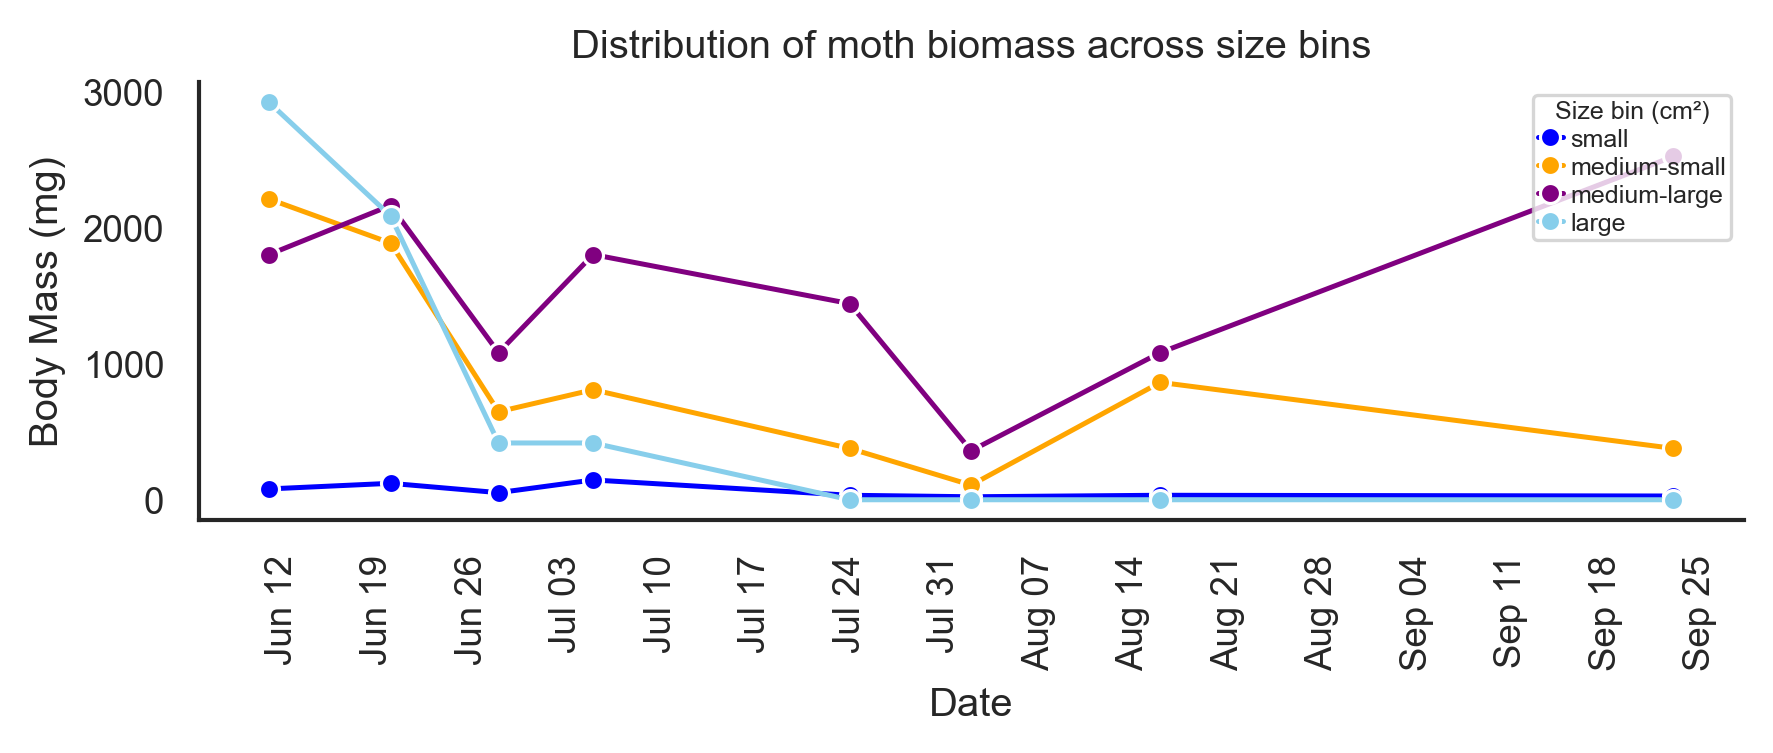

(                                filePath_pred  \
 8178  WS6up/2023_WS6up_0611_0200_WSCT7480.JPG   
 7703  WS6up/2023_WS6up_0611_0225_WSCT7485.JPG   
 7702  WS6up/2023_WS6up_0611_0225_WSCT7485.JPG   
 7701  WS6up/2023_WS6up_0611_0225_WSCT7485.JPG   
 7700  WS6up/2023_WS6up_0611_0225_WSCT7485.JPG   
 ...                                       ...   
 3061  WS6up/2023_WS6up_0923_0110_WSCT8513.JPG   
 3062  WS6up/2023_WS6up_0923_0110_WSCT8513.JPG   
 3063  WS6up/2023_WS6up_0923_0110_WSCT8513.JPG   
 438   WS6up/2023_WS6up_0923_2245_WSCT8484.JPG   
 4650  WS6up/2023_WS6up_0923_0005_WSCT8500.JPG   
 
                                fileName  year_pred site_pred      X_Min  \
 8178  2023_WS6up_0611_0200_WSCT7480.JPG       2023     WS6up  3719.2078   
 7703  2023_WS6up_0611_0225_WSCT7485.JPG       2023     WS6up  4445.4434   
 7702  2023_WS6up_0611_0225_WSCT7485.JPG       2023     WS6up  2940.2378   
 7701  2023_WS6up_0611_0225_WSCT7485.JPG       2023     WS6up  2861.4180   
 7700  2023_WS6up_

In [131]:
runtrends("2023", "WS6up")

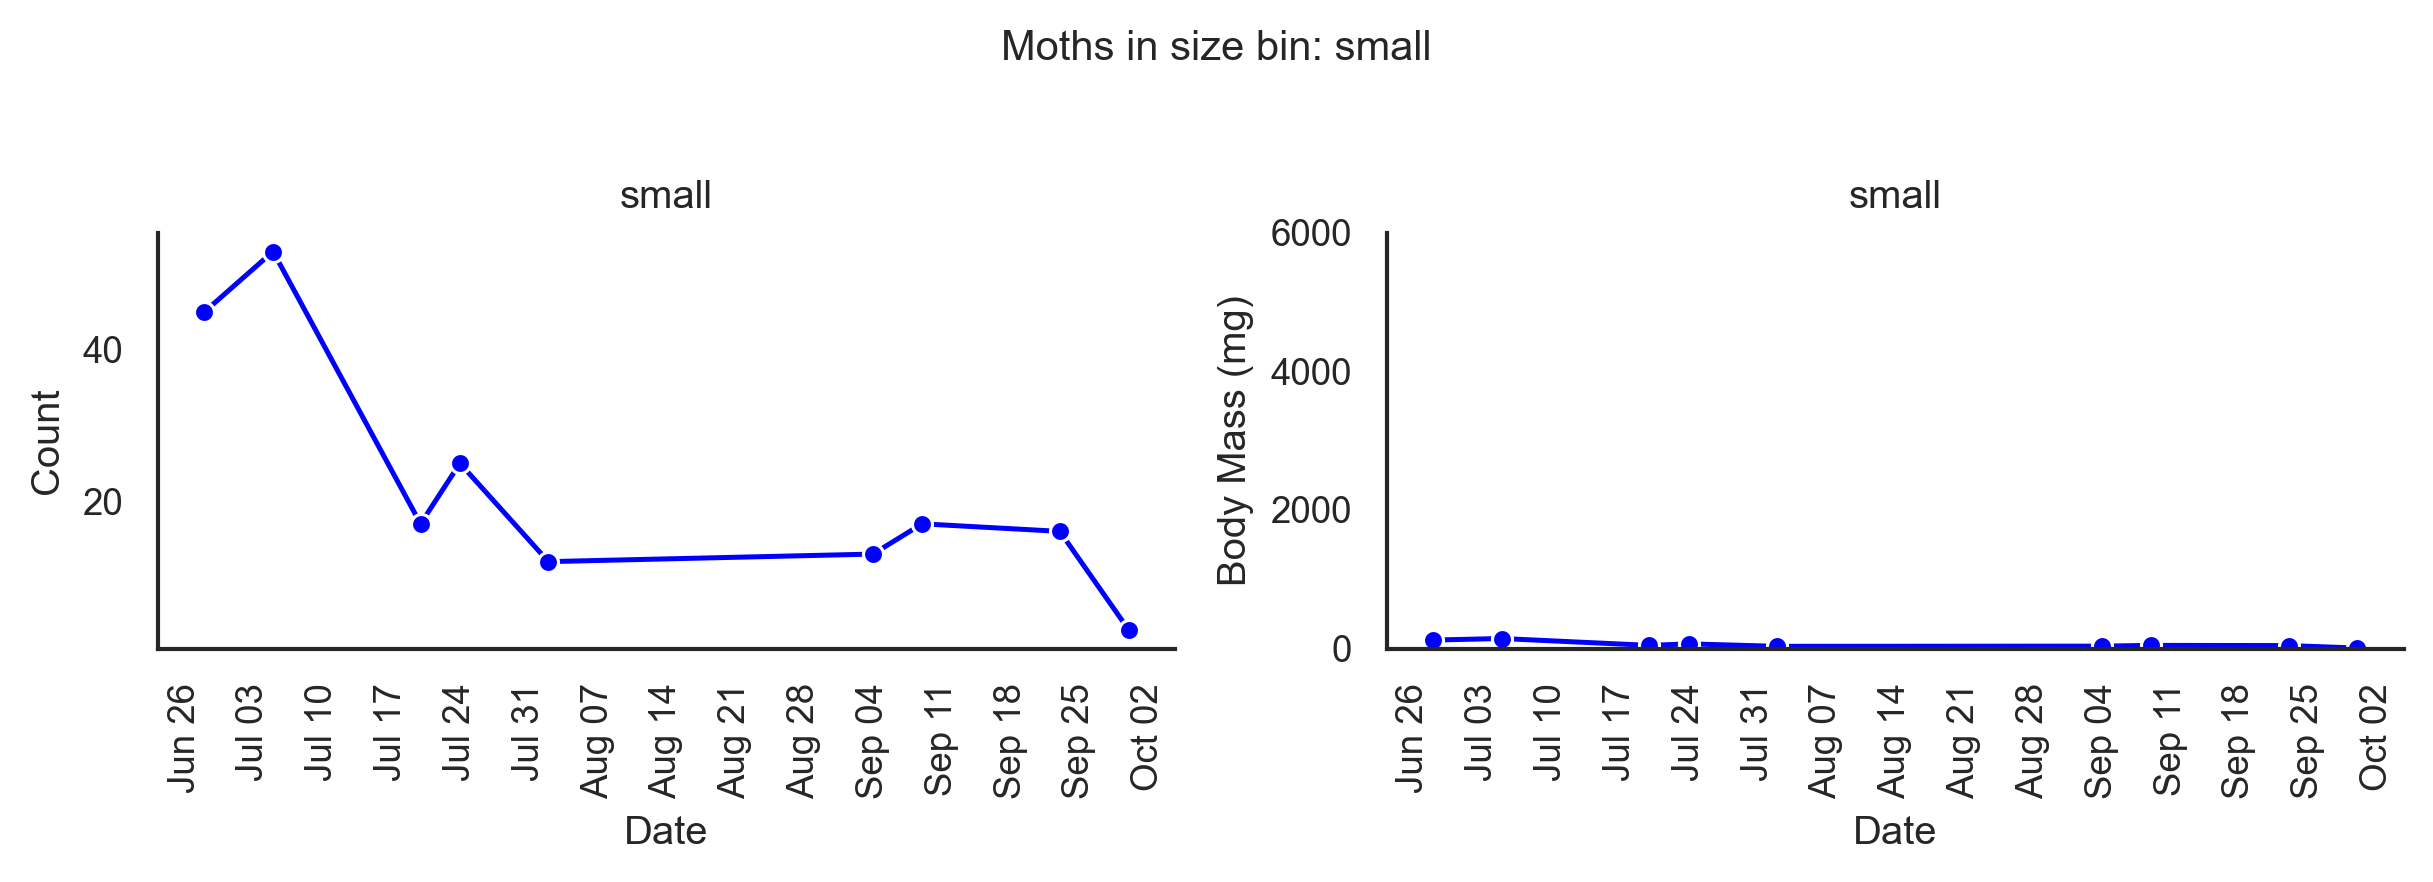

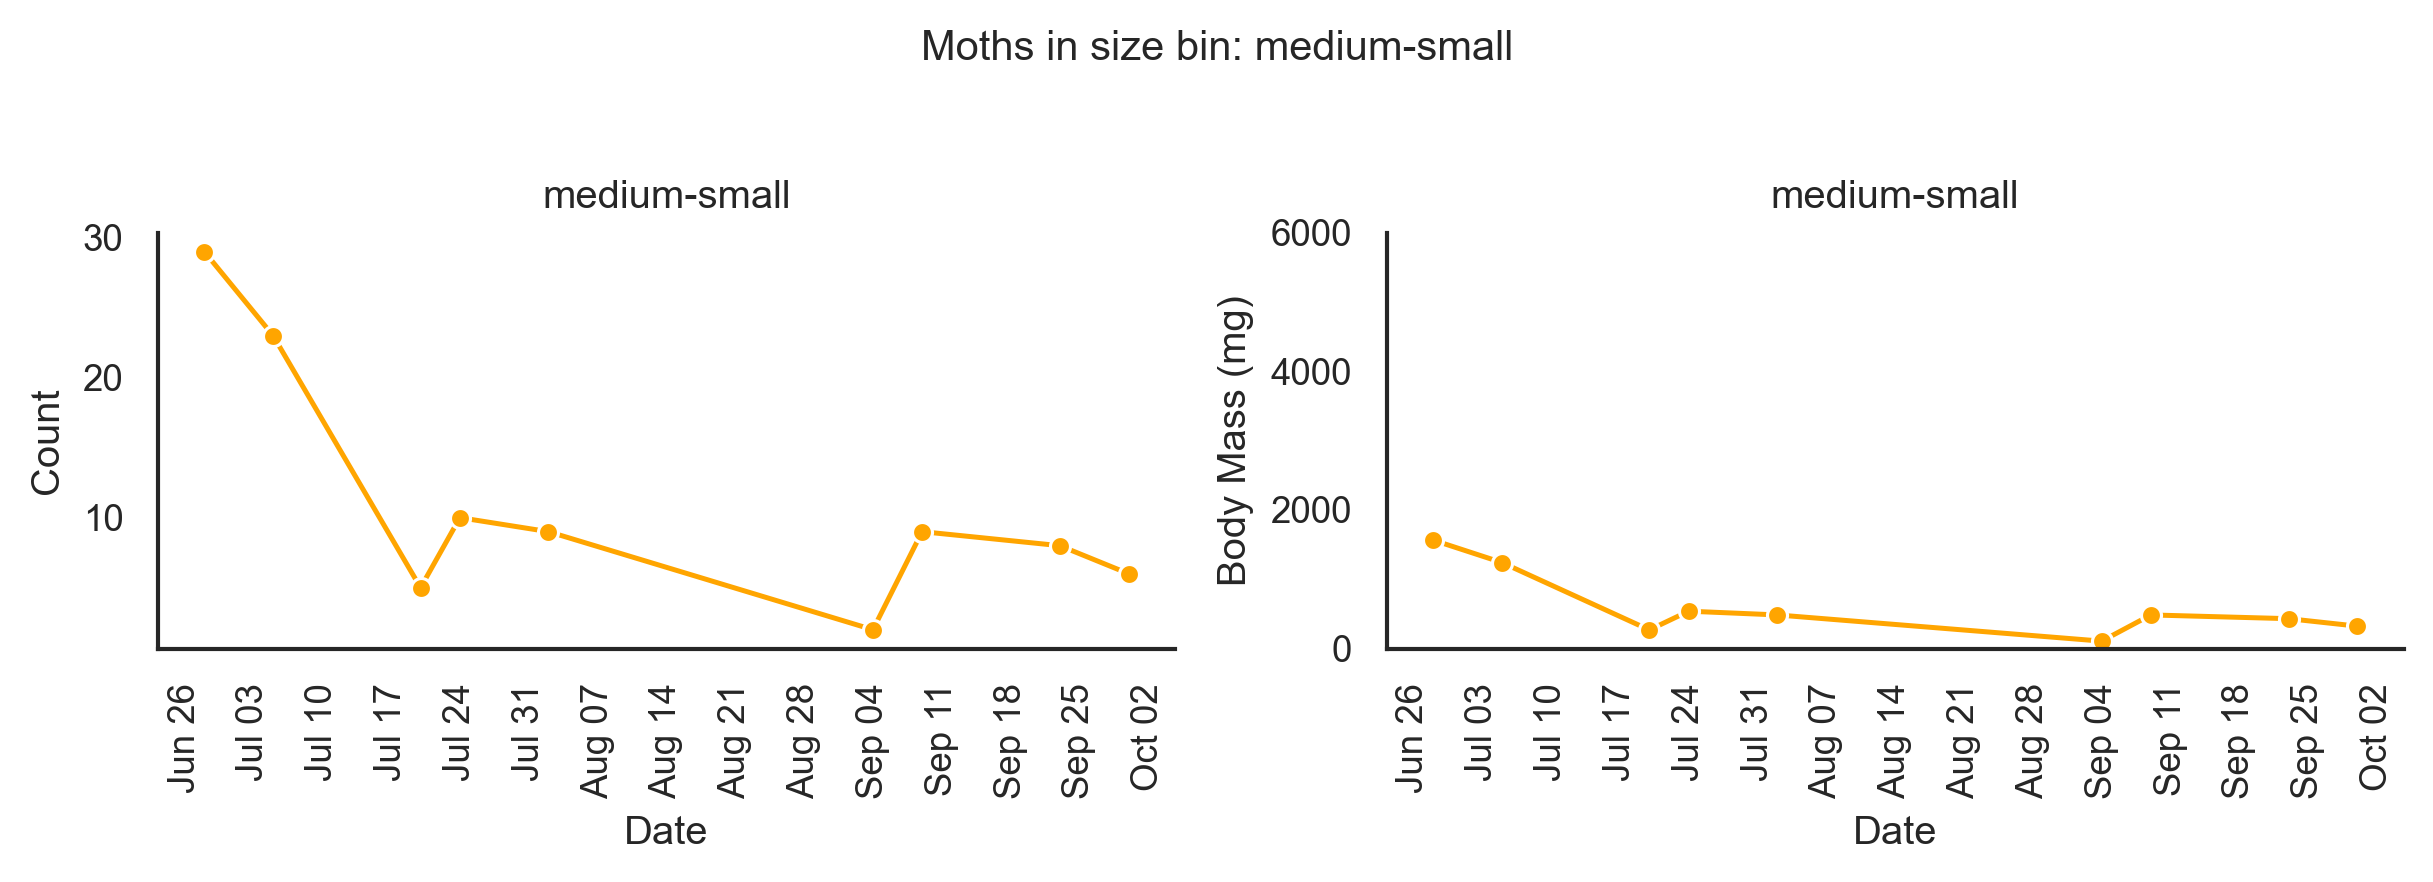

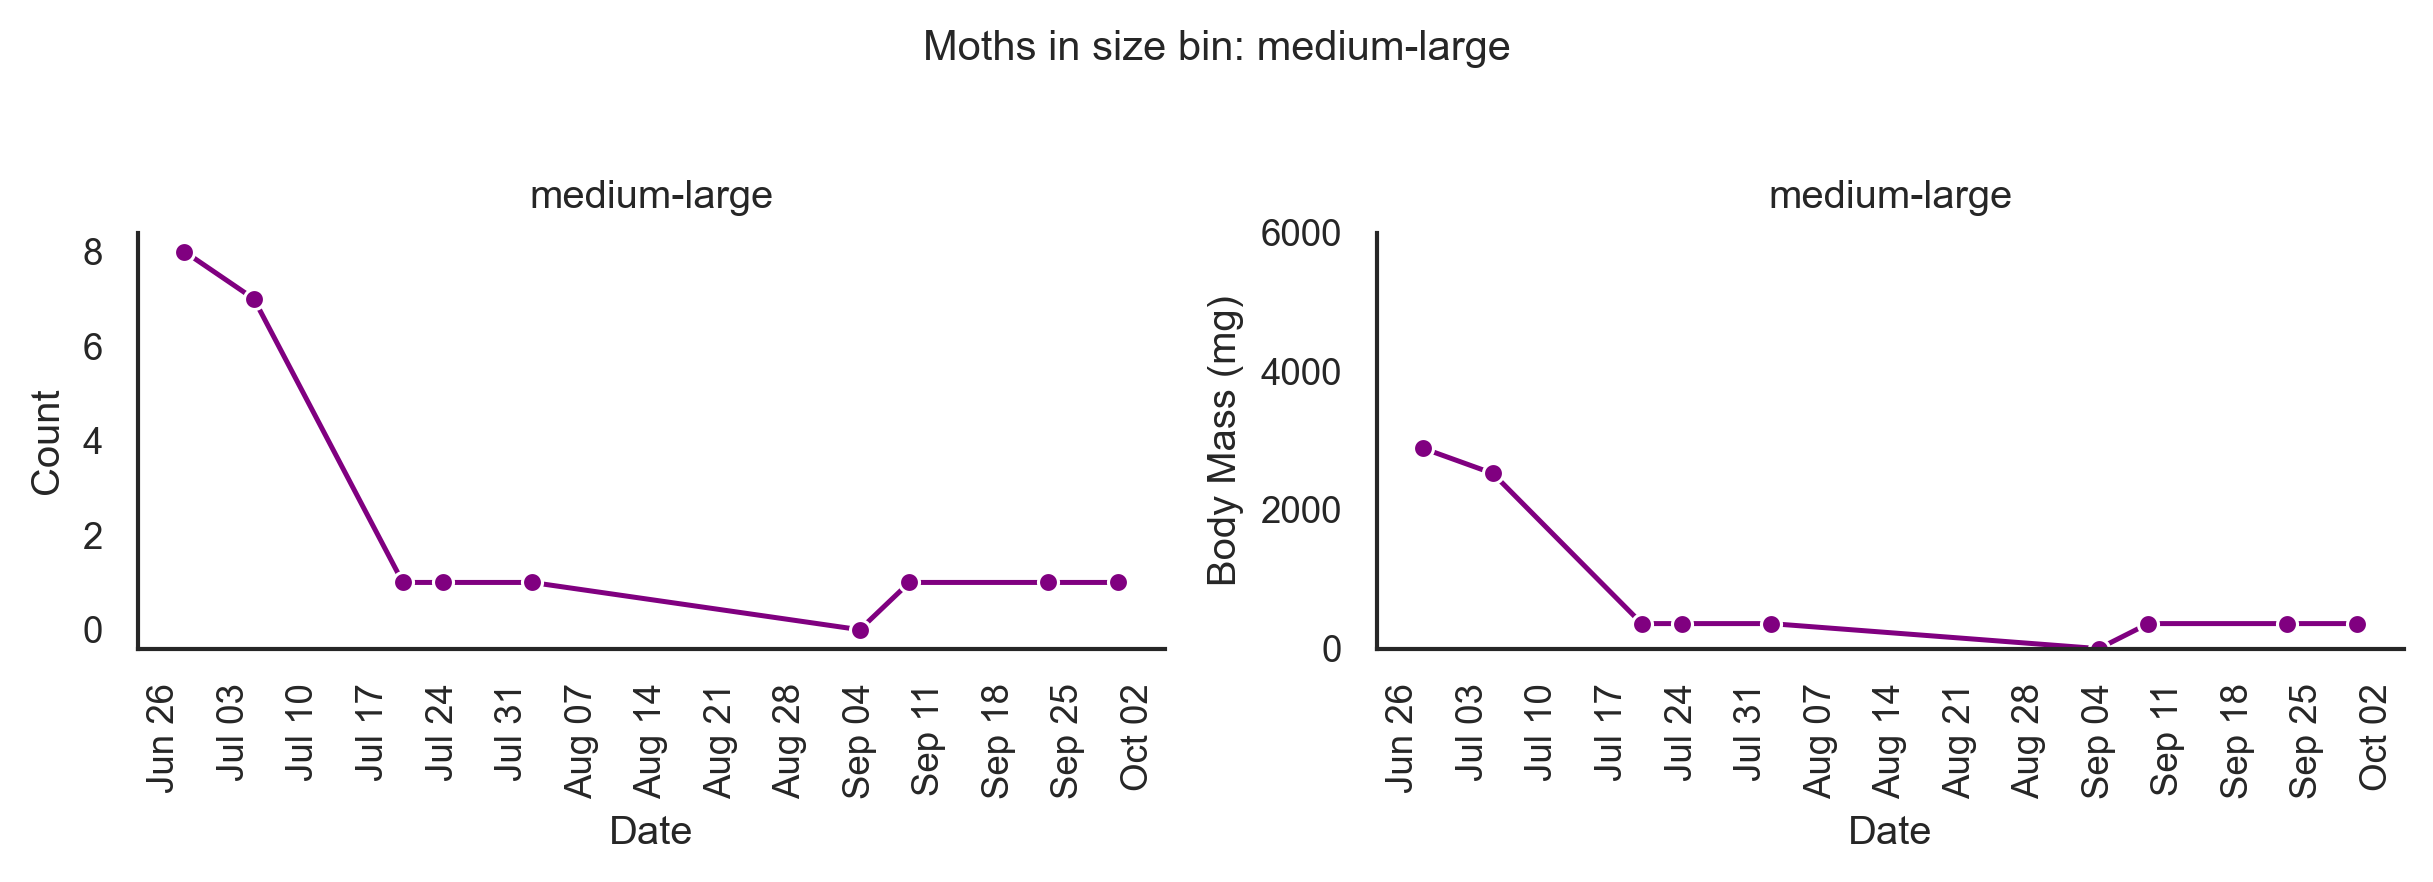

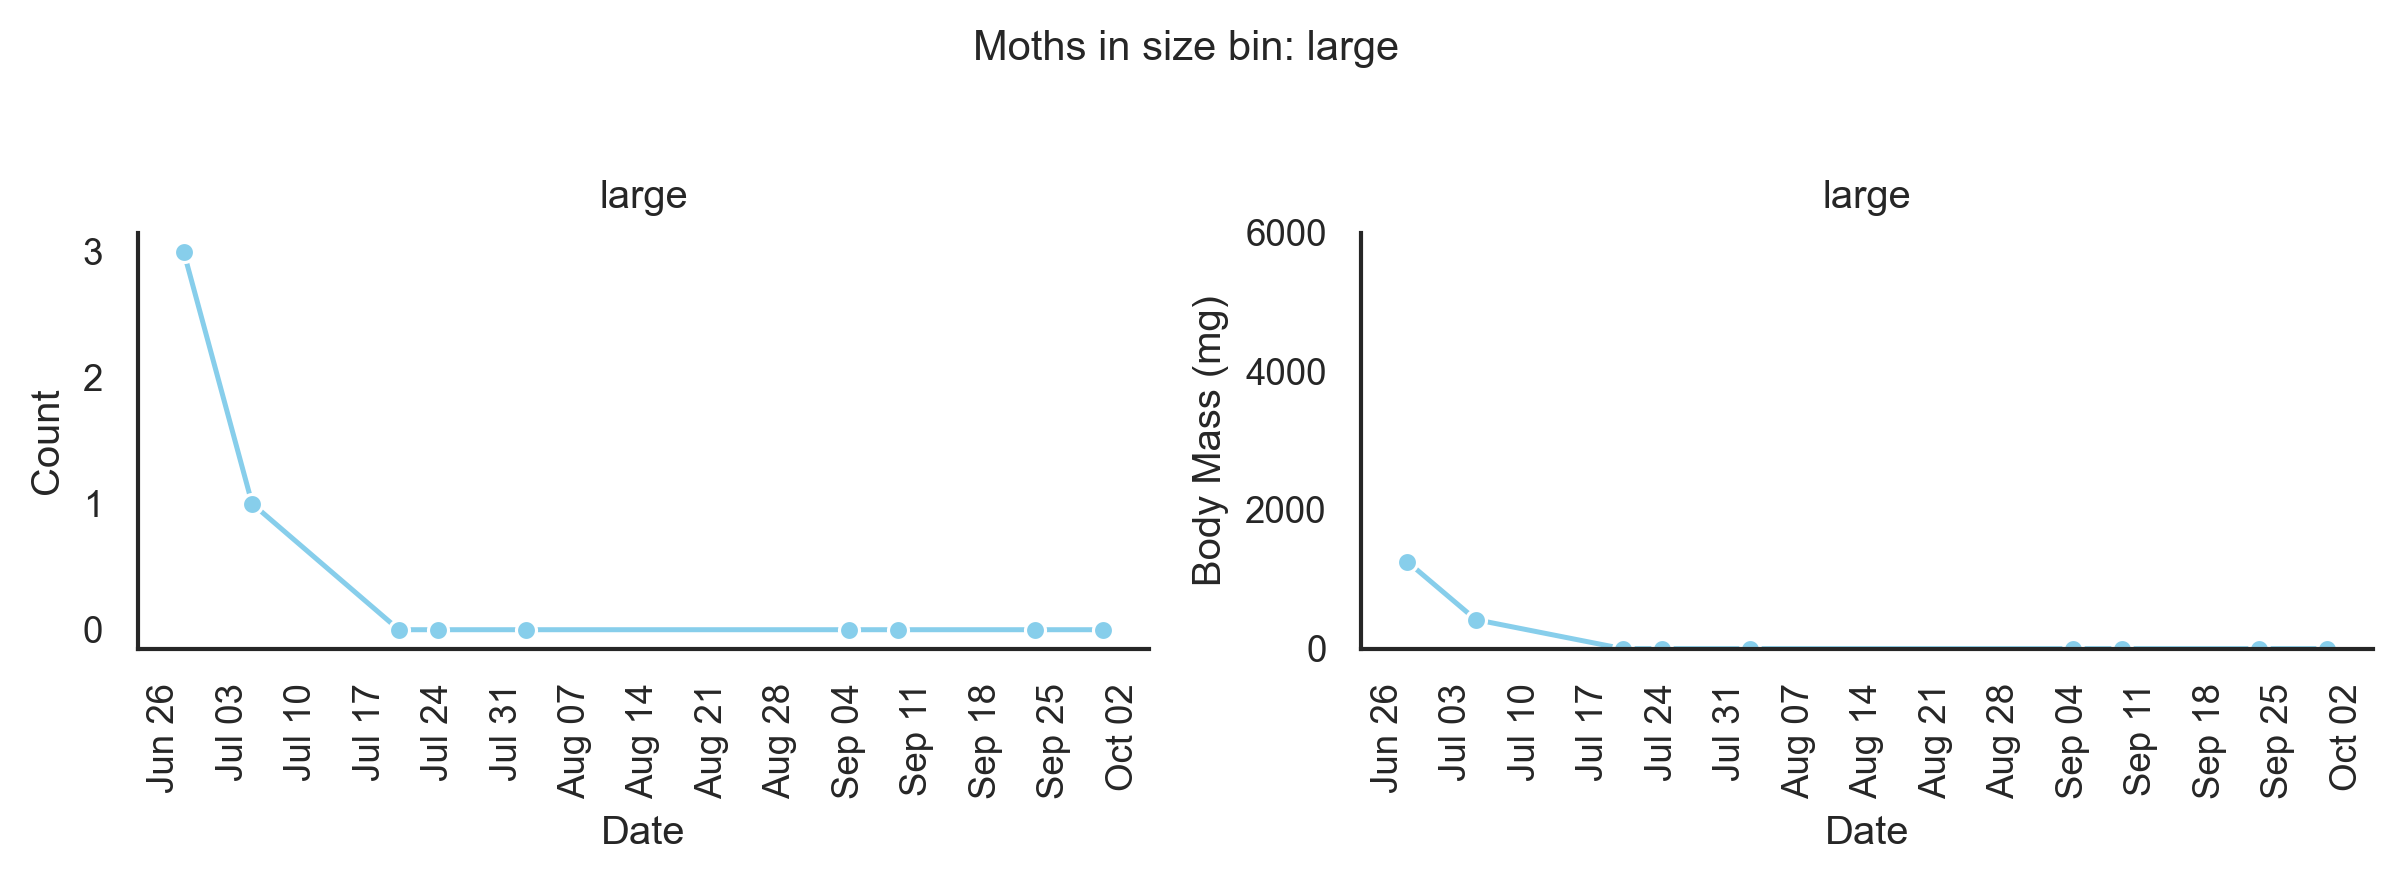

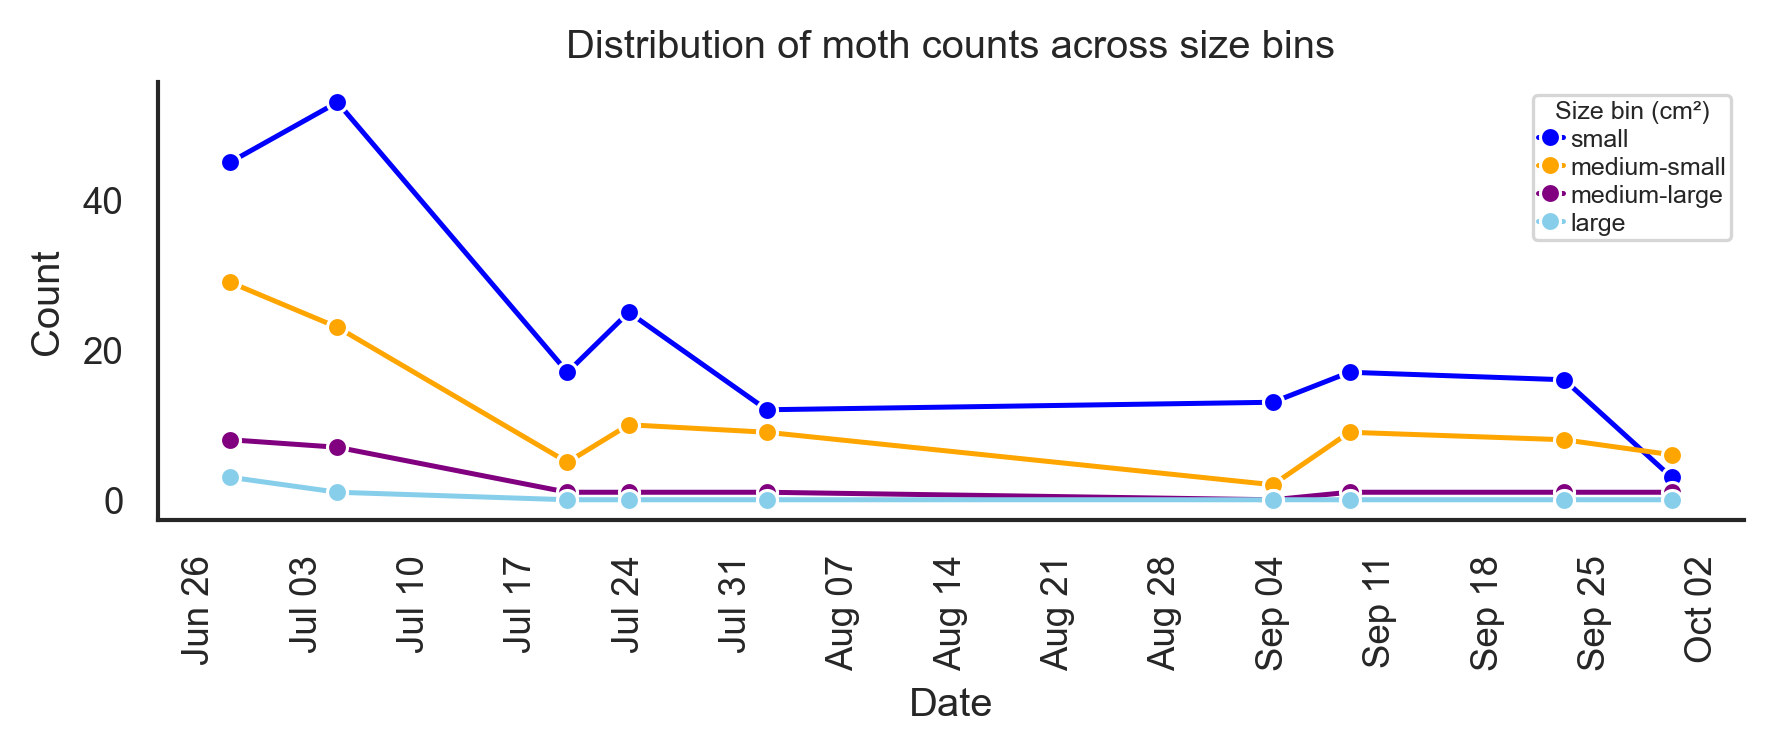

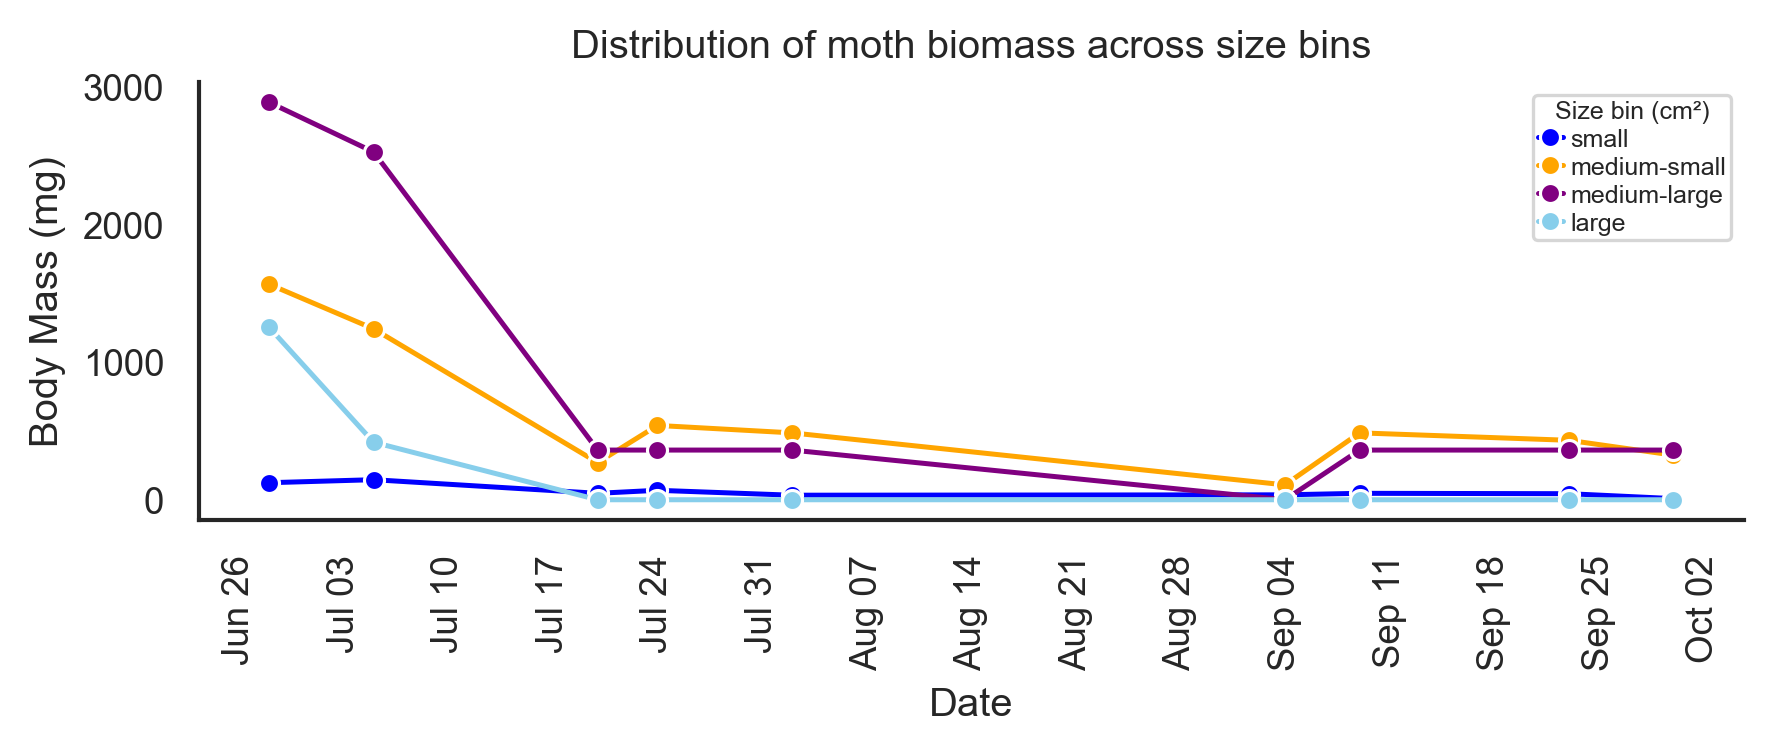

(                                   filePath_pred  \
 7744   WS6low/2023_WS6low_0628_0005_WSCT0075.JPG   
 11101  WS6low/2023_WS6low_0628_0235_WSCT0105.JPG   
 11100  WS6low/2023_WS6low_0628_0235_WSCT0105.JPG   
 11099  WS6low/2023_WS6low_0628_0235_WSCT0105.JPG   
 11098  WS6low/2023_WS6low_0628_0235_WSCT0105.JPG   
 ...                                          ...   
 10781  WS6low/2023_WS6low_0930_0005_WSCT0927.JPG   
 10782  WS6low/2023_WS6low_0930_0005_WSCT0927.JPG   
 10783  WS6low/2023_WS6low_0930_0005_WSCT0927.JPG   
 10785  WS6low/2023_WS6low_0930_0005_WSCT0927.JPG   
 10119  WS6low/2023_WS6low_0930_0235_WSCT0957.JPG   
 
                                  fileName  year_pred site_pred      X_Min  \
 7744   2023_WS6low_0628_0005_WSCT0075.JPG       2023    WS6low  4511.4110   
 11101  2023_WS6low_0628_0235_WSCT0105.JPG       2023    WS6low  5482.5600   
 11100  2023_WS6low_0628_0235_WSCT0105.JPG       2023    WS6low  4496.7905   
 11099  2023_WS6low_0628_0235_WSCT0105.JPG       2

In [132]:
runtrends("2023", "WS6low")